In [1]:
# ==========================================================
# Phase 5 Environment Setup and Library Check
# This step prepares the Google Colab environment and loads
# the libraries required for SHAP explainability analysis.
# ==========================================================

import sys
import subprocess
import importlib.util
import warnings

# Install SHAP only if it is not already available.
if importlib.util.find_spec("shap") is None:
    print("SHAP is not installed. Installing SHAP...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "shap"
    ])
else:
    print("SHAP is already installed.")

# Import the required libraries.
import os
import json
import zipfile
import shutil
import platform
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import shap

# Reduce unnecessary warning messages.
warnings.filterwarnings("ignore", category=FutureWarning)

# Set a fixed random seed for reproducibility.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display the main environment information.
print("\n" + "=" * 60)
print("PHASE 5 ENVIRONMENT CHECK")
print("=" * 60)
print("Python version       :", platform.python_version())
print("Pandas version       :", pd.__version__)
print("NumPy version        :", np.__version__)
print("Scikit-learn version :", sklearn.__version__)
print("SHAP version         :", shap.__version__)
print("Joblib version       :", joblib.__version__)
print("Random state         :", RANDOM_STATE)
print("=" * 60)
print("Environment setup completed successfully.")

SHAP is already installed.

PHASE 5 ENVIRONMENT CHECK
Python version       : 3.12.13
Pandas version       : 2.2.2
NumPy version        : 2.0.2
Scikit-learn version : 1.6.1
SHAP version         : 0.52.0
Joblib version       : 1.5.3
Random state         : 42
Environment setup completed successfully.


In [2]:
# ==========================================================
# Upload and Extract Phase 3 and Phase 4 Output Files
# This step uploads the preprocessing and model-development
# ZIP archives and extracts them into separate folders.
# ==========================================================

from google.colab import files

# Upload both ZIP archives together.
print("Please upload the following two ZIP files:")
print("1. Phase_3_Preprocessing_Outputs.zip")
print("2. Phase_4_Model_Development_Outputs.zip\n")

uploaded_files = files.upload()

# Identify the uploaded Phase 3 and Phase 4 ZIP files.
phase3_zip = None
phase4_zip = None

for uploaded_name in uploaded_files.keys():
    name_lower = uploaded_name.lower()

    if (
        "phase_3" in name_lower
        and "preprocessing" in name_lower
        and uploaded_name.endswith(".zip")
    ):
        phase3_zip = uploaded_name

    if (
        "phase_4" in name_lower
        and "model" in name_lower
        and uploaded_name.endswith(".zip")
    ):
        phase4_zip = uploaded_name

# Stop with a clear message if either ZIP file is missing.
if phase3_zip is None:
    raise FileNotFoundError(
        "The Phase 3 preprocessing ZIP file was not detected."
    )

if phase4_zip is None:
    raise FileNotFoundError(
        "The Phase 4 model-development ZIP file was not detected."
    )

# Define the extraction folders.
PHASE3_DIR = Path("/content/phase3_outputs")
PHASE4_DIR = Path("/content/phase4_outputs")

# Remove old folders if this cell is run again.
if PHASE3_DIR.exists():
    shutil.rmtree(PHASE3_DIR)

if PHASE4_DIR.exists():
    shutil.rmtree(PHASE4_DIR)

PHASE3_DIR.mkdir(parents=True, exist_ok=True)
PHASE4_DIR.mkdir(parents=True, exist_ok=True)

# Extract both ZIP archives.
with zipfile.ZipFile(phase3_zip, "r") as zip_file:
    zip_file.extractall(PHASE3_DIR)

with zipfile.ZipFile(phase4_zip, "r") as zip_file:
    zip_file.extractall(PHASE4_DIR)

# Define the files required for Phase 5.
required_phase3_files = {
    "X_train_processed.csv",
    "X_test_processed.csv",
    "y_train.csv",
    "y_test.csv",
    "train_reference.csv",
    "test_reference.csv",
    "feature_name_mapping.csv",
    "preprocessor.joblib",
    "preprocessing_metadata.json",
    "cleaned_telco_churn.csv"
}

required_phase4_files = {
    "selected_model.joblib",
    "model_feature_names.csv",
    "test_predictions.csv",
    "test_customer_predictions.csv",
    "training_oof_predictions.csv",
    "best_model_parameters.json",
    "model_metadata.json"
}

# Collect the extracted filenames.
phase3_extracted_files = {
    file_path.name
    for file_path in PHASE3_DIR.rglob("*")
    if file_path.is_file()
}

phase4_extracted_files = {
    file_path.name
    for file_path in PHASE4_DIR.rglob("*")
    if file_path.is_file()
}

# Check whether any required files are missing.
missing_phase3 = sorted(
    required_phase3_files - phase3_extracted_files
)

missing_phase4 = sorted(
    required_phase4_files - phase4_extracted_files
)

if missing_phase3:
    raise FileNotFoundError(
        f"Missing required Phase 3 files: {missing_phase3}"
    )

if missing_phase4:
    raise FileNotFoundError(
        f"Missing required Phase 4 files: {missing_phase4}"
    )

# Display the extraction summary.
print("\n" + "=" * 65)
print("PHASE 3 AND PHASE 4 FILE EXTRACTION")
print("=" * 65)
print("Detected Phase 3 ZIP :", phase3_zip)
print("Detected Phase 4 ZIP :", phase4_zip)
print("Phase 3 folder       :", PHASE3_DIR)
print("Phase 4 folder       :", PHASE4_DIR)
print("Phase 3 files found  :", len(phase3_extracted_files))
print("Phase 4 files found  :", len(phase4_extracted_files))
print("Missing Phase 3 files:", len(missing_phase3))
print("Missing Phase 4 files:", len(missing_phase4))
print("=" * 65)
print("Both ZIP archives were extracted and validated successfully.")

Please upload the following two ZIP files:
1. Phase_3_Preprocessing_Outputs.zip
2. Phase_4_Model_Development_Outputs.zip



Saving Phase_4_Model_Development_Outputs.zip to Phase_4_Model_Development_Outputs (1).zip
Saving Phase_3_Preprocessing_Outputs.zip to Phase_3_Preprocessing_Outputs (1).zip

PHASE 3 AND PHASE 4 FILE EXTRACTION
Detected Phase 3 ZIP : Phase_3_Preprocessing_Outputs (1).zip
Detected Phase 4 ZIP : Phase_4_Model_Development_Outputs (1).zip
Phase 3 folder       : /content/phase3_outputs
Phase 4 folder       : /content/phase4_outputs
Phase 3 files found  : 10
Phase 4 files found  : 15
Missing Phase 3 files: 0
Missing Phase 4 files: 0
Both ZIP archives were extracted and validated successfully.


In [3]:
# ==========================================================
# Load the Model, Datasets, References, and Metadata
# This step loads the selected Gradient Boosting model and
# all important Phase 3 and Phase 4 files required for SHAP.
# ==========================================================

# Create the folder where Phase 5 outputs will later be saved.
PHASE5_DIR = Path("/content/phase5_outputs")
PHASE5_DIR.mkdir(parents=True, exist_ok=True)

# Define a helper function that safely locates extracted files.
# This also works if a ZIP archive contains an additional folder.
def find_extracted_file(base_folder, filename):
    matches = list(base_folder.rglob(filename))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Required file was not found: {filename}"
        )

    if len(matches) > 1:
        raise RuntimeError(
            f"Multiple copies of {filename} were found: {matches}"
        )

    return matches[0]

# Locate the required Phase 3 files.
phase3_paths = {
    "X_train": find_extracted_file(
        PHASE3_DIR, "X_train_processed.csv"
    ),
    "X_test": find_extracted_file(
        PHASE3_DIR, "X_test_processed.csv"
    ),
    "y_train": find_extracted_file(
        PHASE3_DIR, "y_train.csv"
    ),
    "y_test": find_extracted_file(
        PHASE3_DIR, "y_test.csv"
    ),
    "train_reference": find_extracted_file(
        PHASE3_DIR, "train_reference.csv"
    ),
    "test_reference": find_extracted_file(
        PHASE3_DIR, "test_reference.csv"
    ),
    "feature_mapping": find_extracted_file(
        PHASE3_DIR, "feature_name_mapping.csv"
    ),
    "preprocessing_metadata": find_extracted_file(
        PHASE3_DIR, "preprocessing_metadata.json"
    )
}

# Locate the required Phase 4 files.
phase4_paths = {
    "selected_model": find_extracted_file(
        PHASE4_DIR, "selected_model.joblib"
    ),
    "model_feature_names": find_extracted_file(
        PHASE4_DIR, "model_feature_names.csv"
    ),
    "test_predictions": find_extracted_file(
        PHASE4_DIR, "test_predictions.csv"
    ),
    "test_customer_predictions": find_extracted_file(
        PHASE4_DIR, "test_customer_predictions.csv"
    ),
    "training_oof_predictions": find_extracted_file(
        PHASE4_DIR, "training_oof_predictions.csv"
    ),
    "best_parameters": find_extracted_file(
        PHASE4_DIR, "best_model_parameters.json"
    ),
    "model_metadata": find_extracted_file(
        PHASE4_DIR, "model_metadata.json"
    )
}

# Load the processed model datasets.
X_train = pd.read_csv(phase3_paths["X_train"])
X_test = pd.read_csv(phase3_paths["X_test"])

# Load the target variables as one-dimensional integer Series.
y_train = pd.read_csv(
    phase3_paths["y_train"]
).iloc[:, 0].astype(int)

y_test = pd.read_csv(
    phase3_paths["y_test"]
).iloc[:, 0].astype(int)

# Load the original customer reference datasets.
train_reference = pd.read_csv(
    phase3_paths["train_reference"]
)

test_reference = pd.read_csv(
    phase3_paths["test_reference"]
)

# Load the feature mapping and saved feature-order file.
feature_name_mapping = pd.read_csv(
    phase3_paths["feature_mapping"]
)

model_feature_names_df = pd.read_csv(
    phase4_paths["model_feature_names"]
)

# Sort by the saved feature position and create the feature list.
model_feature_names_df = model_feature_names_df.sort_values(
    "FeaturePosition"
).reset_index(drop=True)

model_feature_names = (
    model_feature_names_df["FeatureName"]
    .astype(str)
    .tolist()
)

# Load the saved prediction files.
test_predictions = pd.read_csv(
    phase4_paths["test_predictions"]
)

test_customer_predictions = pd.read_csv(
    phase4_paths["test_customer_predictions"]
)

training_oof_predictions = pd.read_csv(
    phase4_paths["training_oof_predictions"]
)

# Load the saved JSON metadata.
with open(
    phase3_paths["preprocessing_metadata"],
    "r",
    encoding="utf-8"
) as file:
    preprocessing_metadata = json.load(file)

with open(
    phase4_paths["best_parameters"],
    "r",
    encoding="utf-8"
) as file:
    best_model_parameters = json.load(file)

with open(
    phase4_paths["model_metadata"],
    "r",
    encoding="utf-8"
) as file:
    model_metadata = json.load(file)

# Load the exact trained model selected during Phase 4.
selected_model = joblib.load(
    phase4_paths["selected_model"]
)

# Store important model settings for later cells.
POSITIVE_CLASS = int(
    model_metadata.get("positive_class", 1)
)

DEFAULT_THRESHOLD = float(
    model_metadata.get("default_threshold", 0.50)
)

SELECTED_THRESHOLD = float(
    model_metadata.get("selected_threshold", 0.27)
)

# Display a clear loading summary.
print("\n" + "=" * 68)
print("PHASE 5 DATA AND MODEL LOADING SUMMARY")
print("=" * 68)
print("Selected model             :", type(selected_model).__name__)
print("Positive class             :", POSITIVE_CLASS, "(Customer churn)")
print("Default threshold          :", DEFAULT_THRESHOLD)
print("Selected threshold         :", SELECTED_THRESHOLD)
print("-" * 68)
print("Training processed shape   :", X_train.shape)
print("Testing processed shape    :", X_test.shape)
print("Training target shape      :", y_train.shape)
print("Testing target shape       :", y_test.shape)
print("Training reference shape   :", train_reference.shape)
print("Testing reference shape    :", test_reference.shape)
print("Feature mapping shape      :", feature_name_mapping.shape)
print("Saved model feature count  :", len(model_feature_names))
print("Test predictions shape     :", test_predictions.shape)
print("Customer predictions shape :", test_customer_predictions.shape)
print("Training OOF shape         :", training_oof_predictions.shape)
print("Phase 5 output folder      :", PHASE5_DIR)
print("=" * 68)
print("All required Phase 5 data and model files loaded successfully.")


PHASE 5 DATA AND MODEL LOADING SUMMARY
Selected model             : GradientBoostingClassifier
Positive class             : 1 (Customer churn)
Default threshold          : 0.5
Selected threshold         : 0.27
--------------------------------------------------------------------
Training processed shape   : (5625, 45)
Testing processed shape    : (1407, 45)
Training target shape      : (5625,)
Testing target shape       : (1407,)
Training reference shape   : (5625, 22)
Testing reference shape    : (1407, 22)
Feature mapping shape      : (45, 2)
Saved model feature count  : 45
Test predictions shape     : (1407, 9)
Customer predictions shape : (1407, 28)
Training OOF shape         : (5625, 8)
Phase 5 output folder      : /content/phase5_outputs
All required Phase 5 data and model files loaded successfully.


In [4]:
# ==========================================================
# Validate the Loaded Model and Phase 4 Predictions
# This step confirms data shapes, feature order, customer-ID
# alignment, and reproduction of the saved probabilities.
# ==========================================================

validation_errors = []

# Define a helper function for collecting validation errors.
def require(condition, message):
    if not condition:
        validation_errors.append(message)

# Read expected values from the saved metadata.
expected_training_rows = int(
    model_metadata["training_records"]
)

expected_testing_rows = int(
    model_metadata["testing_records"]
)

expected_feature_count = int(
    model_metadata["processed_feature_count"]
)

# Validate the processed dataset dimensions.
require(
    X_train.shape == (
        expected_training_rows,
        expected_feature_count
    ),
    f"Unexpected training shape: {X_train.shape}"
)

require(
    X_test.shape == (
        expected_testing_rows,
        expected_feature_count
    ),
    f"Unexpected testing shape: {X_test.shape}"
)

# Validate target lengths.
require(
    len(y_train) == len(X_train),
    "Training target length does not match training features."
)

require(
    len(y_test) == len(X_test),
    "Testing target length does not match testing features."
)

# Validate exact model feature order.
require(
    X_train.columns.tolist() == model_feature_names,
    "Training feature order does not match the saved model order."
)

require(
    X_test.columns.tolist() == model_feature_names,
    "Testing feature order does not match the saved model order."
)

# Validate the Phase 3 and Phase 4 feature-name files.
require(
    feature_name_mapping["ProcessedFeatureName"]
    .astype(str)
    .tolist() == model_feature_names,
    "Phase 3 feature mapping does not match Phase 4 feature order."
)

# Validate customer-ID alignment.
require(
    test_reference["customerID"].astype(str).tolist()
    == test_predictions["customerID"].astype(str).tolist(),
    "Testing customer IDs are not aligned."
)

# Validate actual churn values.
require(
    np.array_equal(
        y_test.to_numpy(),
        test_predictions["ActualChurn"].astype(int).to_numpy()
    ),
    "Testing targets do not match the saved Phase 4 predictions."
)

# Confirm the location of the positive churn class.
positive_class_locations = np.where(
    selected_model.classes_ == POSITIVE_CLASS
)[0]

require(
    len(positive_class_locations) == 1,
    "The positive churn class could not be identified."
)

positive_class_index = int(
    positive_class_locations[0]
)

# Recalculate model probabilities.
current_probabilities = selected_model.predict_proba(
    X_test
)[:, positive_class_index]

saved_probabilities = test_predictions[
    "ChurnProbability"
].to_numpy(dtype=float)

MAX_PROBABILITY_DIFFERENCE = float(
    np.max(
        np.abs(
            current_probabilities - saved_probabilities
        )
    )
)

require(
    np.allclose(
        current_probabilities,
        saved_probabilities,
        atol=1e-10,
        rtol=1e-10
    ),
    (
        "Current probabilities do not match Phase 4. "
        f"Maximum difference: {MAX_PROBABILITY_DIFFERENCE}"
    )
)

# Recreate predictions using the selected threshold.
current_predictions = (
    current_probabilities >= SELECTED_THRESHOLD
).astype(int)

require(
    np.array_equal(
        current_predictions,
        test_predictions["PredictedChurn"]
        .astype(int)
        .to_numpy()
    ),
    "Threshold-based predictions do not match Phase 4."
)

# Validate targets and numerical data.
require(
    set(np.unique(y_train)).issubset({0, 1}),
    "Training target contains unexpected values."
)

require(
    set(np.unique(y_test)).issubset({0, 1}),
    "Testing target contains unexpected values."
)

require(
    np.isfinite(X_train.to_numpy()).all(),
    "Training features contain missing or infinite values."
)

require(
    np.isfinite(X_test.to_numpy()).all(),
    "Testing features contain missing or infinite values."
)

# Stop the notebook if any validation failed.
if validation_errors:
    raise AssertionError(
        "\n".join(validation_errors)
    )

# Display the validation results.
print("\n" + "=" * 70)
print("MODEL AND DATA VALIDATION")
print("=" * 70)
print("Model class                       :", type(selected_model).__name__)
print("Model classes                     :", selected_model.classes_)
print("Positive class index              :", positive_class_index)
print("Training rows                     :", len(X_train))
print("Testing rows                      :", len(X_test))
print("Processed feature count           :", X_test.shape[1])
print("Customer IDs aligned              : Yes")
print("Target values aligned             : Yes")
print("Feature order aligned             : Yes")
print("Probabilities reproduced          : Yes")
print(
    "Maximum probability difference    :",
    f"{MAX_PROBABILITY_DIFFERENCE:.12e}"
)
print("Selected-threshold labels matched : Yes")
print("Missing or infinite values        : None")
print("=" * 70)
print("All model and dataset validation checks passed successfully.")


MODEL AND DATA VALIDATION
Model class                       : GradientBoostingClassifier
Model classes                     : [0 1]
Positive class index              : 1
Training rows                     : 5625
Testing rows                      : 1407
Processed feature count           : 45
Customer IDs aligned              : Yes
Target values aligned             : Yes
Feature order aligned             : Yes
Probabilities reproduced          : Yes
Maximum probability difference    : 9.714451465470e-17
Selected-threshold labels matched : Yes
Missing or infinite values        : None
All model and dataset validation checks passed successfully.


In [5]:
# ==========================================================
# Create the Processed-to-Original Feature Mapping
# This step connects all 45 processed model features to their
# corresponding original customer variables.
# ==========================================================

# Identify the original model-input features from the
# customer reference dataset.
original_feature_names = [
    column
    for column in test_reference.columns
    if column not in {
        "customerID",
        "Churn",
        "ChurnEncoded"
    }
]

# Create readable display names for Power BI.
feature_display_names = {
    "gender": "Gender",
    "SeniorCitizen": "Senior Citizen",
    "Partner": "Partner",
    "Dependents": "Dependents",
    "tenure": "Tenure",
    "PhoneService": "Phone Service",
    "MultipleLines": "Multiple Lines",
    "InternetService": "Internet Service",
    "OnlineSecurity": "Online Security",
    "OnlineBackup": "Online Backup",
    "DeviceProtection": "Device Protection",
    "TechSupport": "Technical Support",
    "StreamingTV": "Streaming TV",
    "StreamingMovies": "Streaming Movies",
    "Contract": "Contract",
    "PaperlessBilling": "Paperless Billing",
    "PaymentMethod": "Payment Method",
    "MonthlyCharges": "Monthly Charges",
    "TotalCharges": "Total Charges"
}

categorical_features = set(
    preprocessing_metadata["categorical_features"]
)

continuous_features = set(
    preprocessing_metadata["continuous_scaled_features"]
)

binary_features = set(
    preprocessing_metadata["binary_numeric_features"]
)

# Identify the original feature for each processed column.
def find_original_feature(processed_name):
    # Continuous and binary features keep their original name.
    if processed_name in original_feature_names:
        return processed_name

    # One-hot encoded features begin with the original name.
    candidates = [
        feature
        for feature in original_feature_names
        if processed_name.startswith(feature + "_")
    ]

    if not candidates:
        raise ValueError(
            "No original feature mapping was found for: "
            f"{processed_name}"
        )

    # Use the longest match to avoid prefix ambiguity.
    return max(candidates, key=len)

# Extract a readable encoded category where relevant.
def extract_processed_category(
    processed_name,
    original_name
):
    if processed_name == original_name:
        return ""

    category = processed_name[
        len(original_name) + 1:
    ]

    return category.replace("_", " ")

# Build the complete mapping table.
mapping_rows = []

for position, processed_name in enumerate(
    model_feature_names,
    start=1
):
    original_name = find_original_feature(
        processed_name
    )

    if original_name in categorical_features:
        feature_type = "One-hot encoded categorical"
    elif original_name in continuous_features:
        feature_type = "Standardized continuous"
    elif original_name in binary_features:
        feature_type = "Binary numerical"
    else:
        feature_type = "Other"

    mapping_rows.append({
        "ProcessedFeaturePosition": position,
        "ProcessedFeatureName": processed_name,
        "OriginalFeatureName": original_name,
        "OriginalFeatureDisplayName": (
            feature_display_names.get(
                original_name,
                original_name
            )
        ),
        "ProcessedCategory": extract_processed_category(
            processed_name,
            original_name
        ),
        "FeatureType": feature_type
    })

shap_feature_mapping = pd.DataFrame(
    mapping_rows
)

# Validate the mapping.
if (
    shap_feature_mapping[
        "ProcessedFeatureName"
    ].tolist() != model_feature_names
):
    raise AssertionError(
        "The processed feature mapping order is incorrect."
    )

if not shap_feature_mapping[
    "OriginalFeatureName"
].isin(original_feature_names).all():
    raise AssertionError(
        "Some processed features were not mapped correctly."
    )

# Save the mapping.
shap_feature_mapping_path = (
    PHASE5_DIR / "shap_feature_mapping.csv"
)

shap_feature_mapping.to_csv(
    shap_feature_mapping_path,
    index=False
)

# Display the mapping summary.
print("\n" + "=" * 72)
print("SHAP FEATURE MAPPING SUMMARY")
print("=" * 72)
print("Processed model features :", len(shap_feature_mapping))
print("Original input features  :", len(original_feature_names))
print("Categorical features     :", len(categorical_features))
print("Continuous features      :", len(continuous_features))
print("Binary features          :", len(binary_features))
print("Saved mapping file       :", shap_feature_mapping_path)
print("=" * 72)

display(
    shap_feature_mapping.head(15)
)

print("The SHAP feature mapping was created successfully.")


SHAP FEATURE MAPPING SUMMARY
Processed model features : 45
Original input features  : 19
Categorical features     : 15
Continuous features      : 3
Binary features          : 1
Saved mapping file       : /content/phase5_outputs/shap_feature_mapping.csv


,ProcessedFeaturePosition,ProcessedFeatureName,OriginalFeatureName,OriginalFeatureDisplayName,ProcessedCategory,FeatureType
0,1,tenure,tenure,Tenure,,Standardized continuous
1,2,MonthlyCharges,MonthlyCharges,Monthly Charges,,Standardized continuous
2,3,TotalCharges,TotalCharges,Total Charges,,Standardized continuous
3,4,SeniorCitizen,SeniorCitizen,Senior Citizen,,Binary numerical
4,5,gender_Female,gender,Gender,Female,One-hot encoded categorical
5,6,gender_Male,gender,Gender,Male,One-hot encoded categorical
6,7,Partner_No,Partner,Partner,No,One-hot encoded categorical
7,8,Partner_Yes,Partner,Partner,Yes,One-hot encoded categorical
8,9,Dependents_No,Dependents,Dependents,No,One-hot encoded categorical
9,10,Dependents_Yes,Dependents,Dependents,Yes,One-hot encoded categorical


The SHAP feature mapping was created successfully.


In [6]:
# ==========================================================
# Initialize the SHAP Tree Explainer
# This step first attempts to create probability-scale SHAP
# explanations using an interventional background sample.
# ==========================================================

# Create a reproducible background sample from training data.
BACKGROUND_SAMPLE_SIZE = min(
    100,
    len(X_train)
)

shap_background = shap.sample(
    X_train,
    BACKGROUND_SAMPLE_SIZE,
    random_state=RANDOM_STATE
)

SHAP_FALLBACK_REASON = None

# Probability-scale SHAP values are easier to communicate.
# If they are not supported, the code safely falls back to
# raw model-output SHAP values.
try:
    explainer = shap.TreeExplainer(
        selected_model,
        data=shap_background,
        feature_perturbation="interventional",
        model_output="probability"
    )

    SHAP_OUTPUT_SCALE = "probability"

    EXPLAINER_TYPE = (
        "TreeExplainer with interventional background"
    )

    probability_scale_supported = True

except Exception as error:
    SHAP_FALLBACK_REASON = (
        f"{type(error).__name__}: {error}"
    )

    explainer = shap.TreeExplainer(
        selected_model
    )

    SHAP_OUTPUT_SCALE = "raw_model_output"

    EXPLAINER_TYPE = (
        "TreeExplainer with tree-path-dependent method"
    )

    probability_scale_supported = False

# Display the explainer configuration.
print("\n" + "=" * 72)
print("SHAP EXPLAINER CONFIGURATION")
print("=" * 72)
print("Selected model          :", type(selected_model).__name__)
print("Explainer               :", EXPLAINER_TYPE)
print("Background sample rows  :", len(shap_background))
print("Positive class          :", POSITIVE_CLASS, "(Churn)")
print("SHAP output scale       :", SHAP_OUTPUT_SCALE)
print(
    "Probability scale used :",
    "Yes" if probability_scale_supported else "No"
)

if SHAP_FALLBACK_REASON is not None:
    print(
        "Fallback reason        :",
        SHAP_FALLBACK_REASON
    )

print("=" * 72)
print("The SHAP explainer was initialized successfully.")


SHAP EXPLAINER CONFIGURATION
Selected model          : GradientBoostingClassifier
Explainer               : TreeExplainer with interventional background
Background sample rows  : 100
Positive class          : 1 (Churn)
SHAP output scale       : probability
Probability scale used : Yes
The SHAP explainer was initialized successfully.


In [7]:
# ==========================================================
# Calculate SHAP Values for the Independent Test Dataset
# This step generates one explanation for every test customer
# and safely normalizes different possible SHAP output forms.
# ==========================================================

print("Calculating SHAP values for all test customers...")

# Calculate SHAP explanations.
shap_result = explainer(
    X_test,
    check_additivity=False
)

# Normalize different possible SHAP output structures.
def normalize_binary_shap_output(
    result,
    positive_class_index,
    n_rows,
    n_features
):
    # Some SHAP versions may return a list.
    if isinstance(result, list):
        selected_result = (
            result[positive_class_index]
            if len(result) > 1
            else result[0]
        )

        if isinstance(
            selected_result,
            shap.Explanation
        ):
            values = np.asarray(
                selected_result.values,
                dtype=float
            )

            base_source = (
                selected_result.base_values
            )

        else:
            values = np.asarray(
                selected_result,
                dtype=float
            )

            base_source = getattr(
                explainer,
                "expected_value",
                0.0
            )

    else:
        if isinstance(result, shap.Explanation):
            values = np.asarray(
                result.values,
                dtype=float
            )

            base_source = result.base_values

        else:
            values = np.asarray(
                result,
                dtype=float
            )

            base_source = getattr(
                explainer,
                "expected_value",
                0.0
            )

    # Handle possible three-dimensional class outputs.
    if values.ndim == 3:
        expected_last_class_shape = (
            n_rows,
            n_features,
            len(selected_model.classes_)
        )

        expected_first_class_shape = (
            len(selected_model.classes_),
            n_rows,
            n_features
        )

        if values.shape == expected_last_class_shape:
            values = values[
                :,
                :,
                positive_class_index
            ]

        elif values.shape == expected_first_class_shape:
            values = values[
                positive_class_index,
                :,
                :
            ]

        else:
            raise ValueError(
                "Unsupported three-dimensional SHAP shape: "
                f"{values.shape}"
            )

    # Final SHAP values must be customer-by-feature.
    if (
        values.ndim != 2
        or values.shape != (n_rows, n_features)
    ):
        raise ValueError(
            "Unexpected SHAP values shape: "
            f"{values.shape}"
        )

    # Normalize the base values.
    base_values = np.asarray(
        base_source,
        dtype=float
    )

    if base_values.ndim == 0:
        base_values = np.repeat(
            float(base_values),
            n_rows
        )

    elif base_values.ndim == 1:
        if base_values.size == 1:
            base_values = np.repeat(
                float(base_values[0]),
                n_rows
            )

        elif (
            base_values.size
            == len(selected_model.classes_)
        ):
            base_values = np.repeat(
                float(
                    base_values[
                        positive_class_index
                    ]
                ),
                n_rows
            )

        elif base_values.size != n_rows:
            raise ValueError(
                "Unexpected SHAP base-values shape: "
                f"{base_values.shape}"
            )

    elif base_values.ndim == 2:
        if base_values.shape == (
            n_rows,
            len(selected_model.classes_)
        ):
            base_values = base_values[
                :,
                positive_class_index
            ]

        elif base_values.shape == (
            n_rows,
            1
        ):
            base_values = base_values[:, 0]

        else:
            raise ValueError(
                "Unexpected SHAP base-values shape: "
                f"{base_values.shape}"
            )

    else:
        raise ValueError(
            "Unsupported SHAP base-values shape: "
            f"{base_values.shape}"
        )

    return (
        values,
        base_values.astype(float)
    )

# Normalize the SHAP output.
shap_values, shap_base_values = (
    normalize_binary_shap_output(
        result=shap_result,
        positive_class_index=positive_class_index,
        n_rows=len(X_test),
        n_features=X_test.shape[1]
    )
)

# Confirm that the SHAP output is valid.
if not np.isfinite(shap_values).all():
    raise ValueError(
        "The SHAP values contain missing or infinite values."
    )

if not np.isfinite(shap_base_values).all():
    raise ValueError(
        "The SHAP base values contain invalid values."
    )

# Create a normalized SHAP Explanation object.
processed_explanation = shap.Explanation(
    values=shap_values,
    base_values=shap_base_values,
    data=X_test.to_numpy(),
    feature_names=model_feature_names
)

# Display the output summary.
print("\n" + "=" * 72)
print("SHAP CALCULATION SUMMARY")
print("=" * 72)
print("Test customers explained :", shap_values.shape[0])
print("Features per customer     :", shap_values.shape[1])
print("SHAP values shape         :", shap_values.shape)
print("Base-values shape         :", shap_base_values.shape)
print("SHAP output scale         :", SHAP_OUTPUT_SCALE)
print("Missing SHAP values       :", np.isnan(shap_values).sum())
print(
    "Infinite SHAP values      :",
    np.isinf(shap_values).sum()
)
print("=" * 72)
print("SHAP values were calculated successfully.")

Calculating SHAP values for all test customers...

SHAP CALCULATION SUMMARY
Test customers explained : 1407
Features per customer     : 45
SHAP values shape         : (1407, 45)
Base-values shape         : (1407,)
SHAP output scale         : probability
Missing SHAP values       : 0
Infinite SHAP values      : 0
SHAP values were calculated successfully.


In [8]:
# ==========================================================
# Validate SHAP Additivity
# This step checks that the base value plus all SHAP feature
# contributions reconstructs the selected model output.
# ==========================================================

# Calculate the total feature contribution for each customer.
shap_contribution_sum = shap_values.sum(
    axis=1
)

# Reconstruct the explained model output.
reconstructed_model_output = (
    shap_base_values
    + shap_contribution_sum
)

# Select the correct model output for comparison.
if SHAP_OUTPUT_SCALE == "probability":
    model_output_for_validation = (
        current_probabilities
    )

    reconstructed_probability = (
        reconstructed_model_output
    )

else:
    model_output_for_validation = np.asarray(
        selected_model.decision_function(
            X_test
        ),
        dtype=float
    )

    # Convert raw binary model scores into probabilities.
    reconstructed_probability = (
        1
        / (
            1
            + np.exp(
                -reconstructed_model_output
            )
        )
    )

# Calculate reconstruction errors.
ADDITIVITY_TOLERANCE = 1e-6

absolute_additivity_error = np.abs(
    reconstructed_model_output
    - model_output_for_validation
)

MAX_ADDITIVITY_ERROR = float(
    absolute_additivity_error.max()
)

MEAN_ADDITIVITY_ERROR = float(
    absolute_additivity_error.mean()
)

# Create the complete customer-level validation file.
additivity_validation = pd.DataFrame({
    "TestRowIndex": np.arange(len(X_test)),
    "customerID": (
        test_reference["customerID"]
        .astype(str)
        .to_numpy()
    ),
    "SHAPOutputScale": SHAP_OUTPUT_SCALE,
    "BaseValue": shap_base_values,
    "SumOfSHAPValues": shap_contribution_sum,
    "ReconstructedModelOutput": (
        reconstructed_model_output
    ),
    "ModelOutput": model_output_for_validation,
    "ReconstructedChurnProbability": (
        reconstructed_probability
    ),
    "ModelChurnProbability": (
        current_probabilities
    ),
    "AbsoluteAdditivityError": (
        absolute_additivity_error
    ),
    "AdditivityPassed": (
        absolute_additivity_error
        <= ADDITIVITY_TOLERANCE
    )
})

# Save the additivity validation file.
additivity_validation_path = (
    PHASE5_DIR
    / "shap_additivity_validation.csv"
)

additivity_validation.to_csv(
    additivity_validation_path,
    index=False
)

# Stop if additivity does not pass.
if not additivity_validation[
    "AdditivityPassed"
].all():
    failed_count = int(
        (
            ~additivity_validation[
                "AdditivityPassed"
            ]
        ).sum()
    )

    raise AssertionError(
        f"SHAP additivity failed for {failed_count} customers."
    )

# Display the validation summary.
print("\n" + "=" * 74)
print("SHAP ADDITIVITY VALIDATION")
print("=" * 74)
print("Customers validated         :", len(additivity_validation))
print("SHAP output scale           :", SHAP_OUTPUT_SCALE)
print("Additivity tolerance        :", ADDITIVITY_TOLERANCE)
print(
    "Maximum additivity error    :",
    f"{MAX_ADDITIVITY_ERROR:.12e}"
)
print(
    "Mean additivity error       :",
    f"{MEAN_ADDITIVITY_ERROR:.12e}"
)
print(
    "Customers passing validation:",
    int(
        additivity_validation[
            "AdditivityPassed"
        ].sum()
    )
)
print("Customers failing validation:", 0)
print("Saved validation file       :", additivity_validation_path)
print("=" * 74)
print("All SHAP additivity checks passed successfully.")

display(
    additivity_validation.head()
)


SHAP ADDITIVITY VALIDATION
Customers validated         : 1407
SHAP output scale           : probability
Additivity tolerance        : 1e-06
Maximum additivity error    : 3.381192770213e-09
Mean additivity error       : 9.082925055713e-10
Customers passing validation: 1407
Customers failing validation: 0
Saved validation file       : /content/phase5_outputs/shap_additivity_validation.csv
All SHAP additivity checks passed successfully.


,TestRowIndex,customerID,SHAPOutputScale,BaseValue,SumOfSHAPValues,ReconstructedModelOutput,ModelOutput,ReconstructedChurnProbability,ModelChurnProbability,AbsoluteAdditivityError,AdditivityPassed
0,0,0604-THJFP,probability,0.320269,-0.274277,0.045992,0.045992,0.045992,0.045992,1.602825e-09,True
1,1,4059-IIEBK,probability,0.320269,0.284801,0.605069,0.605069,0.605069,0.605069,1.315750e-09,True
2,2,2228-BZDEE,probability,0.320269,-0.291062,0.029206,0.029206,0.029206,0.029206,4.510065e-10,True
3,3,2839-RFSQE,probability,0.320269,-0.151576,0.168693,0.168693,0.168693,0.168693,9.188138e-10,True
4,4,5360-LJCNJ,probability,0.320269,-0.184844,0.135425,0.135425,0.135425,0.135425,1.227639e-09,True


In [9]:
# ==========================================================
# Calculate Global SHAP Importance for Processed Features
# This step measures the average influence of each of the
# 45 model features across all test customers.
# ==========================================================

# Calculate global SHAP statistics.
processed_mean_absolute_shap = np.mean(
    np.abs(shap_values),
    axis=0
)

processed_mean_signed_shap = np.mean(
    shap_values,
    axis=0
)

processed_mean_positive_shap = np.mean(
    np.where(
        shap_values > 0,
        shap_values,
        0.0
    ),
    axis=0
)

processed_mean_negative_shap = np.mean(
    np.where(
        shap_values < 0,
        shap_values,
        0.0
    ),
    axis=0
)

# Combine the results with the technical feature mapping.
global_shap_importance_processed = (
    shap_feature_mapping.copy()
)

global_shap_importance_processed[
    "MeanAbsoluteSHAP"
] = processed_mean_absolute_shap

global_shap_importance_processed[
    "MeanSHAP"
] = processed_mean_signed_shap

global_shap_importance_processed[
    "MeanPositiveSHAP"
] = processed_mean_positive_shap

global_shap_importance_processed[
    "MeanNegativeSHAP"
] = processed_mean_negative_shap

global_shap_importance_processed[
    "SHAPOutputScale"
] = SHAP_OUTPUT_SCALE

# Rank features using mean absolute SHAP values.
global_shap_importance_processed = (
    global_shap_importance_processed
    .sort_values(
        "MeanAbsoluteSHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

global_shap_importance_processed.insert(
    0,
    "GlobalImportanceRank",
    np.arange(
        1,
        len(global_shap_importance_processed) + 1
    )
)

# Save the processed-feature importance file.
global_processed_path = (
    PHASE5_DIR
    / "global_shap_importance_processed.csv"
)

global_shap_importance_processed.to_csv(
    global_processed_path,
    index=False
)

# Display the strongest processed features.
print("\n" + "=" * 76)
print("GLOBAL SHAP IMPORTANCE — PROCESSED FEATURES")
print("=" * 76)
print("Processed features analysed :", len(model_feature_names))
print("Importance method           : Mean absolute SHAP value")
print("SHAP output scale           :", SHAP_OUTPUT_SCALE)
print("Saved output                :", global_processed_path)
print("=" * 76)

display(
    global_shap_importance_processed[
        [
            "GlobalImportanceRank",
            "ProcessedFeatureName",
            "OriginalFeatureDisplayName",
            "MeanAbsoluteSHAP",
            "MeanSHAP"
        ]
    ].head(15)
)

print("Processed-feature global importance was created successfully.")


GLOBAL SHAP IMPORTANCE — PROCESSED FEATURES
Processed features analysed : 45
Importance method           : Mean absolute SHAP value
SHAP output scale           : probability
Saved output                : /content/phase5_outputs/global_shap_importance_processed.csv


,GlobalImportanceRank,ProcessedFeatureName,OriginalFeatureDisplayName,MeanAbsoluteSHAP,MeanSHAP
0,1,tenure,Tenure,0.086874,-0.024689
1,2,Contract_Month_to_month,Contract,0.073286,-0.012677
2,3,InternetService_Fiber_optic,Internet Service,0.048444,0.001474
3,4,OnlineSecurity_No,Online Security,0.035766,-0.004926
4,5,TechSupport_No,Technical Support,0.029059,-0.001335
5,6,PaymentMethod_Electronic_check,Payment Method,0.025229,-0.004297
6,7,MonthlyCharges,Monthly Charges,0.024565,0.000905
7,8,Contract_Two_year,Contract,0.012780,-0.001171
8,9,MultipleLines_No,Multiple Lines,0.011517,0.000724
9,10,TotalCharges,Total Charges,0.007523,-0.002292


Processed-feature global importance was created successfully.


In [10]:
# ==========================================================
# Group Processed SHAP Values into Original Features
# This step sums related one-hot encoded contributions so that
# the results can be understood using the 19 original inputs.
# ==========================================================

# Preserve the original feature order from the reference data.
GROUPED_FEATURE_ORDER = (
    original_feature_names.copy()
)

# Create one grouped SHAP column per original feature.
grouped_shap_values_df = pd.DataFrame(
    index=X_test.index
)

for original_feature in GROUPED_FEATURE_ORDER:
    related_processed_features = (
        shap_feature_mapping.loc[
            shap_feature_mapping[
                "OriginalFeatureName"
            ] == original_feature,
            "ProcessedFeatureName"
        ].tolist()
    )

    related_column_indexes = [
        model_feature_names.index(
            processed_feature
        )
        for processed_feature
        in related_processed_features
    ]

    grouped_shap_values_df[
        original_feature
    ] = shap_values[
        :,
        related_column_indexes
    ].sum(axis=1)

# Confirm that grouping preserves the total contribution.
processed_total_contribution = (
    shap_values.sum(axis=1)
)

grouped_total_contribution = (
    grouped_shap_values_df
    .sum(axis=1)
    .to_numpy()
)

GROUPING_MAX_DIFFERENCE = float(
    np.max(
        np.abs(
            processed_total_contribution
            - grouped_total_contribution
        )
    )
)

if GROUPING_MAX_DIFFERENCE > 1e-10:
    raise AssertionError(
        "Grouped SHAP values do not preserve the "
        "processed-feature contribution totals."
    )

# Calculate global grouped-feature importance.
grouped_importance_rows = []

for original_feature in GROUPED_FEATURE_ORDER:
    feature_values = (
        grouped_shap_values_df[
            original_feature
        ].to_numpy(dtype=float)
    )

    grouped_importance_rows.append({
        "OriginalFeatureName": original_feature,
        "OriginalFeatureDisplayName": (
            feature_display_names.get(
                original_feature,
                original_feature
            )
        ),
        "MeanAbsoluteSHAP": float(
            np.mean(
                np.abs(feature_values)
            )
        ),
        "MeanSHAP": float(
            np.mean(feature_values)
        ),
        "MeanPositiveSHAP": float(
            np.mean(
                np.where(
                    feature_values > 0,
                    feature_values,
                    0.0
                )
            )
        ),
        "MeanNegativeSHAP": float(
            np.mean(
                np.where(
                    feature_values < 0,
                    feature_values,
                    0.0
                )
            )
        ),
        "ProcessedFeatureCount": int(
            (
                shap_feature_mapping[
                    "OriginalFeatureName"
                ] == original_feature
            ).sum()
        ),
        "SHAPOutputScale": SHAP_OUTPUT_SCALE
    })

global_shap_importance_grouped = (
    pd.DataFrame(grouped_importance_rows)
    .sort_values(
        "MeanAbsoluteSHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

global_shap_importance_grouped.insert(
    0,
    "GlobalImportanceRank",
    np.arange(
        1,
        len(global_shap_importance_grouped) + 1
    )
)

# Save grouped global importance.
global_grouped_path = (
    PHASE5_DIR
    / "global_shap_importance_grouped.csv"
)

global_shap_importance_grouped.to_csv(
    global_grouped_path,
    index=False
)

# Select prediction information used in later outputs.
prediction_columns = [
    "customerID",
    "ActualChurn",
    "PredictedChurn",
    "ChurnProbability",
    "PredictionThreshold",
    "ActualChurnLabel",
    "PredictedChurnLabel"
]

prediction_info = test_predictions[
    prediction_columns
].copy()

# Create and save wide processed-feature SHAP output.
processed_shap_wide = pd.concat(
    [
        prediction_info.reset_index(drop=True),
        pd.DataFrame(
            shap_values,
            columns=model_feature_names
        )
    ],
    axis=1
)

processed_wide_path = (
    PHASE5_DIR
    / "shap_values_processed_wide.csv"
)

processed_shap_wide.to_csv(
    processed_wide_path,
    index=False
)

# Create and save wide grouped-feature SHAP output.
grouped_shap_wide = pd.concat(
    [
        prediction_info.reset_index(drop=True),
        grouped_shap_values_df.reset_index(
            drop=True
        )
    ],
    axis=1
)

grouped_wide_path = (
    PHASE5_DIR
    / "shap_values_grouped_wide.csv"
)

grouped_shap_wide.to_csv(
    grouped_wide_path,
    index=False
)

# Display the strongest original features.
print("\n" + "=" * 78)
print("GLOBAL SHAP IMPORTANCE — GROUPED ORIGINAL FEATURES")
print("=" * 78)
print("Processed SHAP features    :", len(model_feature_names))
print("Grouped original features  :", len(GROUPED_FEATURE_ORDER))
print(
    "Maximum grouping difference:",
    f"{GROUPING_MAX_DIFFERENCE:.12e}"
)
print("Grouped importance file    :", global_grouped_path)
print("Processed wide file        :", processed_wide_path)
print("Grouped wide file          :", grouped_wide_path)
print("=" * 78)

display(
    global_shap_importance_grouped[
        [
            "GlobalImportanceRank",
            "OriginalFeatureDisplayName",
            "MeanAbsoluteSHAP",
            "MeanSHAP",
            "ProcessedFeatureCount"
        ]
    ].head(15)
)

print("Original-feature SHAP grouping was completed successfully.")


GLOBAL SHAP IMPORTANCE — GROUPED ORIGINAL FEATURES
Processed SHAP features    : 45
Grouped original features  : 19
Maximum grouping difference: 2.220446049250e-16
Grouped importance file    : /content/phase5_outputs/global_shap_importance_grouped.csv
Processed wide file        : /content/phase5_outputs/shap_values_processed_wide.csv
Grouped wide file          : /content/phase5_outputs/shap_values_grouped_wide.csv


,GlobalImportanceRank,OriginalFeatureDisplayName,MeanAbsoluteSHAP,MeanSHAP,ProcessedFeatureCount
0,1,Tenure,0.086874,-0.024689,1
1,2,Contract,0.083423,-0.013719,3
2,3,Internet Service,0.048631,0.001456,3
3,4,Online Security,0.035766,-0.004926,3
4,5,Technical Support,0.029579,-0.001422,3
5,6,Payment Method,0.025229,-0.004297,4
6,7,Monthly Charges,0.024565,0.000905,1
7,8,Multiple Lines,0.011716,0.000711,3
8,9,Paperless Billing,0.010842,-0.000831,2
9,10,Total Charges,0.007523,-0.002292,1


Original-feature SHAP grouping was completed successfully.


In [11]:
# ==========================================================
# Create the Processed-Feature SHAP Long-Format Output
# This step creates a Power BI-friendly table containing one
# row per customer and processed model feature.
# ==========================================================

# Create a customer-by-processed-feature SHAP table.
processed_shap_only = pd.DataFrame(
    shap_values,
    columns=model_feature_names
)

processed_shap_only.insert(
    0,
    "customerID",
    test_reference[
        "customerID"
    ].astype(str).to_numpy()
)

# Convert the processed SHAP table into long format.
processed_shap_long = processed_shap_only.melt(
    id_vars="customerID",
    var_name="ProcessedFeatureName",
    value_name="SHAPValue"
)

# Add processed-to-original feature mapping.
processed_shap_long = processed_shap_long.merge(
    shap_feature_mapping,
    on="ProcessedFeatureName",
    how="left",
    validate="many_to_one"
)

# Create long-format original customer feature values.
original_values_long = test_reference[
    ["customerID"] + GROUPED_FEATURE_ORDER
].copy().melt(
    id_vars="customerID",
    var_name="OriginalFeatureName",
    value_name="OriginalFeatureValue"
)

original_values_long["customerID"] = (
    original_values_long[
        "customerID"
    ].astype(str)
)

# Convert mixed original values into readable text.
original_values_long[
    "OriginalFeatureValue"
] = original_values_long[
    "OriginalFeatureValue"
].astype(str)

# Add the original readable customer value.
processed_shap_long = processed_shap_long.merge(
    original_values_long,
    on=[
        "customerID",
        "OriginalFeatureName"
    ],
    how="left",
    validate="many_to_one"
)

# Add predictions, probabilities, and threshold information.
processed_shap_long = processed_shap_long.merge(
    prediction_info,
    on="customerID",
    how="left",
    validate="many_to_one"
)

# Calculate absolute SHAP contributions.
processed_shap_long[
    "AbsoluteSHAPValue"
] = processed_shap_long[
    "SHAPValue"
].abs()

# Define a very small neutral tolerance.
NEUTRAL_TOLERANCE = 1e-12

# Classify the contribution direction.
processed_shap_long[
    "ContributionDirection"
] = np.select(
    [
        processed_shap_long[
            "SHAPValue"
        ] > NEUTRAL_TOLERANCE,

        processed_shap_long[
            "SHAPValue"
        ] < -NEUTRAL_TOLERANCE
    ],
    [
        "Increases churn risk",
        "Reduces churn risk"
    ],
    default="Neutral"
)

# Add global processed-feature importance rank.
processed_global_rank_map = (
    global_shap_importance_processed
    .set_index("ProcessedFeatureName")[
        "GlobalImportanceRank"
    ]
)

processed_shap_long[
    "GlobalImportanceRank"
] = processed_shap_long[
    "ProcessedFeatureName"
].map(
    processed_global_rank_map
).astype(int)

# Rank contributions separately for each customer.
processed_shap_long[
    "CustomerContributionRank"
] = processed_shap_long.groupby(
    "customerID"
)["AbsoluteSHAPValue"].rank(
    method="first",
    ascending=False
).astype(int)

processed_shap_long[
    "SHAPOutputScale"
] = SHAP_OUTPUT_SCALE

# Sort by customer and contribution strength.
processed_shap_long = (
    processed_shap_long
    .sort_values(
        [
            "customerID",
            "CustomerContributionRank"
        ]
    )
    .reset_index(drop=True)
)

# Validate the expected number of rows.
expected_processed_long_rows = (
    len(X_test)
    * len(model_feature_names)
)

if (
    len(processed_shap_long)
    != expected_processed_long_rows
):
    raise AssertionError(
        "The processed long-format row count is incorrect."
    )

if processed_shap_long[
    "OriginalFeatureName"
].isna().any():
    raise AssertionError(
        "Some processed SHAP rows are missing feature mappings."
    )

if processed_shap_long[
    "OriginalFeatureValue"
].isna().any():
    raise AssertionError(
        "Some processed SHAP rows are missing original values."
    )

# Save the processed long-format file.
processed_long_path = (
    PHASE5_DIR
    / "shap_values_processed_long.csv"
)

processed_shap_long.to_csv(
    processed_long_path,
    index=False
)

# Display the output summary.
print("\n" + "=" * 78)
print("PROCESSED-FEATURE SHAP LONG-FORMAT OUTPUT")
print("=" * 78)
print("Customers                    :", len(X_test))
print("Processed features           :", len(model_feature_names))
print("Expected rows                :", expected_processed_long_rows)
print("Created rows                 :", len(processed_shap_long))
print("Created columns              :", len(processed_shap_long.columns))
print("Missing feature mappings     :", 0)
print("Missing original values      :", 0)
print("Saved file                   :", processed_long_path)
print("=" * 78)

display(
    processed_shap_long.head(10)
)

print("Processed-feature long-format output was created successfully.")


PROCESSED-FEATURE SHAP LONG-FORMAT OUTPUT
Customers                    : 1407
Processed features           : 45
Expected rows                : 63315
Created rows                 : 63315
Created columns              : 20
Missing feature mappings     : 0
Missing original values      : 0
Saved file                   : /content/phase5_outputs/shap_values_processed_long.csv


,customerID,ProcessedFeatureName,SHAPValue,ProcessedFeaturePosition,OriginalFeatureName,OriginalFeatureDisplayName,ProcessedCategory,FeatureType,OriginalFeatureValue,ActualChurn,PredictedChurn,ChurnProbability,PredictionThreshold,ActualChurnLabel,PredictedChurnLabel,AbsoluteSHAPValue,ContributionDirection,GlobalImportanceRank,CustomerContributionRank,SHAPOutputScale
0,0004-TLHLJ,tenure,0.094188,1,tenure,Tenure,,Standardized continuous,4,1,1,0.674912,0.27,Yes,Yes,0.094188,Increases churn risk,1,1,probability
1,0004-TLHLJ,Contract_Month_to_month,0.075870,37,Contract,Contract,Month to month,One-hot encoded categorical,Month-to-month,1,1,0.674912,0.27,Yes,Yes,0.075870,Increases churn risk,2,2,probability
2,0004-TLHLJ,InternetService_Fiber_optic,0.073506,17,InternetService,Internet Service,Fiber optic,One-hot encoded categorical,Fiber optic,1,1,0.674912,0.27,Yes,Yes,0.073506,Increases churn risk,3,3,probability
3,0004-TLHLJ,OnlineSecurity_No,0.048385,19,OnlineSecurity,Online Security,No,One-hot encoded categorical,No,1,1,0.674912,0.27,Yes,Yes,0.048385,Increases churn risk,4,4,probability
4,0004-TLHLJ,TechSupport_No,0.037881,28,TechSupport,Technical Support,No,One-hot encoded categorical,No,1,1,0.674912,0.27,Yes,Yes,0.037881,Increases churn risk,5,5,probability
5,0004-TLHLJ,PaymentMethod_Electronic_check,0.031192,44,PaymentMethod,Payment Method,Electronic check,One-hot encoded categorical,Electronic check,1,1,0.674912,0.27,Yes,Yes,0.031192,Increases churn risk,6,6,probability
6,0004-TLHLJ,MonthlyCharges,-0.018691,2,MonthlyCharges,Monthly Charges,,Standardized continuous,73.9,1,1,0.674912,0.27,Yes,Yes,0.018691,Reduces churn risk,7,7,probability
7,0004-TLHLJ,MultipleLines_No,-0.018287,13,MultipleLines,Multiple Lines,No,One-hot encoded categorical,No,1,1,0.674912,0.27,Yes,Yes,0.018287,Reduces churn risk,9,8,probability
8,0004-TLHLJ,OnlineBackup_No,0.012142,22,OnlineBackup,Online Backup,No,One-hot encoded categorical,No,1,1,0.674912,0.27,Yes,Yes,0.012142,Increases churn risk,11,9,probability
9,0004-TLHLJ,Contract_Two_year,0.009941,39,Contract,Contract,Two year,One-hot encoded categorical,Month-to-month,1,1,0.674912,0.27,Yes,Yes,0.009941,Increases churn risk,8,10,probability


Processed-feature long-format output was created successfully.


In [12]:
# ==========================================================
# Create the Grouped Original-Feature SHAP Long-Format Output
# This step creates the main Power BI explanation table with
# readable original customer feature names and values.
# ==========================================================

# Add customer IDs to the grouped SHAP table.
grouped_shap_only = (
    grouped_shap_values_df.copy()
)

grouped_shap_only.insert(
    0,
    "customerID",
    test_reference[
        "customerID"
    ].astype(str).to_numpy()
)

# Convert grouped SHAP values into long format.
grouped_shap_long = grouped_shap_only.melt(
    id_vars="customerID",
    var_name="OriginalFeatureName",
    value_name="SHAPValue"
)

# Add the original customer values.
grouped_shap_long = grouped_shap_long.merge(
    original_values_long,
    on=[
        "customerID",
        "OriginalFeatureName"
    ],
    how="left",
    validate="one_to_one"
)

# Add prediction information.
grouped_shap_long = grouped_shap_long.merge(
    prediction_info,
    on="customerID",
    how="left",
    validate="many_to_one"
)

# Add readable feature display names.
grouped_shap_long[
    "OriginalFeatureDisplayName"
] = grouped_shap_long[
    "OriginalFeatureName"
].map(
    feature_display_names
).fillna(
    grouped_shap_long[
        "OriginalFeatureName"
    ]
)

# Calculate absolute contributions.
grouped_shap_long[
    "AbsoluteSHAPValue"
] = grouped_shap_long[
    "SHAPValue"
].abs()

# Classify contribution direction.
grouped_shap_long[
    "ContributionDirection"
] = np.select(
    [
        grouped_shap_long[
            "SHAPValue"
        ] > NEUTRAL_TOLERANCE,

        grouped_shap_long[
            "SHAPValue"
        ] < -NEUTRAL_TOLERANCE
    ],
    [
        "Increases churn risk",
        "Reduces churn risk"
    ],
    default="Neutral"
)

# Add global grouped-feature rank.
grouped_global_rank_map = (
    global_shap_importance_grouped
    .set_index("OriginalFeatureName")[
        "GlobalImportanceRank"
    ]
)

grouped_shap_long[
    "GlobalImportanceRank"
] = grouped_shap_long[
    "OriginalFeatureName"
].map(
    grouped_global_rank_map
).astype(int)

# Rank grouped contributions for every customer.
grouped_shap_long[
    "CustomerContributionRank"
] = grouped_shap_long.groupby(
    "customerID"
)["AbsoluteSHAPValue"].rank(
    method="first",
    ascending=False
).astype(int)

grouped_shap_long[
    "SHAPOutputScale"
] = SHAP_OUTPUT_SCALE

# Sort for Power BI.
grouped_shap_long = (
    grouped_shap_long
    .sort_values(
        [
            "customerID",
            "CustomerContributionRank"
        ]
    )
    .reset_index(drop=True)
)

# Validate the expected output size.
expected_grouped_long_rows = (
    len(X_test)
    * len(GROUPED_FEATURE_ORDER)
)

if (
    len(grouped_shap_long)
    != expected_grouped_long_rows
):
    raise AssertionError(
        "The grouped long-format row count is incorrect."
    )

if grouped_shap_long[
    "OriginalFeatureValue"
].isna().any():
    raise AssertionError(
        "Some grouped SHAP rows are missing original values."
    )

# Save the grouped Power BI output.
grouped_long_path = (
    PHASE5_DIR
    / "shap_values_grouped_long.csv"
)

grouped_shap_long.to_csv(
    grouped_long_path,
    index=False
)

# Display the grouped output.
print("\n" + "=" * 78)
print("GROUPED ORIGINAL-FEATURE SHAP LONG-FORMAT OUTPUT")
print("=" * 78)
print("Customers                   :", len(X_test))
print("Original features           :", len(GROUPED_FEATURE_ORDER))
print("Expected rows               :", expected_grouped_long_rows)
print("Created rows                :", len(grouped_shap_long))
print("Created columns             :", len(grouped_shap_long.columns))
print("Missing original values     :", 0)
print("SHAP output scale           :", SHAP_OUTPUT_SCALE)
print("Saved file                  :", grouped_long_path)
print("=" * 78)

display(
    grouped_shap_long.head(10)
)

print("Grouped Power BI SHAP output was created successfully.")


GROUPED ORIGINAL-FEATURE SHAP LONG-FORMAT OUTPUT
Customers                   : 1407
Original features           : 19
Expected rows               : 26733
Created rows                : 26733
Created columns             : 16
Missing original values     : 0
SHAP output scale           : probability
Saved file                  : /content/phase5_outputs/shap_values_grouped_long.csv


,customerID,OriginalFeatureName,SHAPValue,OriginalFeatureValue,ActualChurn,PredictedChurn,ChurnProbability,PredictionThreshold,ActualChurnLabel,PredictedChurnLabel,OriginalFeatureDisplayName,AbsoluteSHAPValue,ContributionDirection,GlobalImportanceRank,CustomerContributionRank,SHAPOutputScale
0,0004-TLHLJ,tenure,0.094188,4,1,1,0.674912,0.27,Yes,Yes,Tenure,0.094188,Increases churn risk,1,1,probability
1,0004-TLHLJ,Contract,0.085422,Month-to-month,1,1,0.674912,0.27,Yes,Yes,Contract,0.085422,Increases churn risk,2,2,probability
2,0004-TLHLJ,InternetService,0.073647,Fiber optic,1,1,0.674912,0.27,Yes,Yes,Internet Service,0.073647,Increases churn risk,3,3,probability
3,0004-TLHLJ,OnlineSecurity,0.048385,No,1,1,0.674912,0.27,Yes,Yes,Online Security,0.048385,Increases churn risk,4,4,probability
4,0004-TLHLJ,TechSupport,0.038974,No,1,1,0.674912,0.27,Yes,Yes,Technical Support,0.038974,Increases churn risk,5,5,probability
5,0004-TLHLJ,PaymentMethod,0.031192,Electronic check,1,1,0.674912,0.27,Yes,Yes,Payment Method,0.031192,Increases churn risk,6,6,probability
6,0004-TLHLJ,MonthlyCharges,-0.018691,73.9,1,1,0.674912,0.27,Yes,Yes,Monthly Charges,0.018691,Reduces churn risk,7,7,probability
7,0004-TLHLJ,MultipleLines,-0.018671,No,1,1,0.674912,0.27,Yes,Yes,Multiple Lines,0.018671,Reduces churn risk,8,8,probability
8,0004-TLHLJ,OnlineBackup,0.012142,No,1,1,0.674912,0.27,Yes,Yes,Online Backup,0.012142,Increases churn risk,11,9,probability
9,0004-TLHLJ,PaperlessBilling,0.012023,Yes,1,1,0.674912,0.27,Yes,Yes,Paperless Billing,0.012023,Increases churn risk,9,10,probability


Grouped Power BI SHAP output was created successfully.


In [13]:
# ==========================================================
# Create Customer-Level Top SHAP Factors and Summaries
# This step identifies the five strongest positive and five
# strongest negative churn factors for every test customer.
# ==========================================================

TOP_FACTORS_PER_DIRECTION = 5

# Select the strongest positive factors per customer.
customer_top_positive_factors = (
    grouped_shap_long[
        grouped_shap_long[
            "SHAPValue"
        ] > NEUTRAL_TOLERANCE
    ]
    .sort_values(
        [
            "customerID",
            "SHAPValue"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "customerID",
        group_keys=False
    )
    .head(TOP_FACTORS_PER_DIRECTION)
    .copy()
)

customer_top_positive_factors[
    "FactorRank"
] = customer_top_positive_factors.groupby(
    "customerID"
).cumcount() + 1

customer_top_positive_factors[
    "FactorType"
] = "Top positive factor"

# Select the strongest negative factors per customer.
customer_top_negative_factors = (
    grouped_shap_long[
        grouped_shap_long[
            "SHAPValue"
        ] < -NEUTRAL_TOLERANCE
    ]
    .sort_values(
        [
            "customerID",
            "SHAPValue"
        ],
        ascending=[
            True,
            True
        ]
    )
    .groupby(
        "customerID",
        group_keys=False
    )
    .head(TOP_FACTORS_PER_DIRECTION)
    .copy()
)

customer_top_negative_factors[
    "FactorRank"
] = customer_top_negative_factors.groupby(
    "customerID"
).cumcount() + 1

customer_top_negative_factors[
    "FactorType"
] = "Top negative factor"

# Create readable explanation text.
def create_contribution_text(row):
    value_text = str(
        row["OriginalFeatureValue"]
    )

    contribution_amount = abs(
        float(row["SHAPValue"])
    )

    direction_word = (
        "increased"
        if row["SHAPValue"] > 0
        else "reduced"
    )

    if SHAP_OUTPUT_SCALE == "probability":
        scale_text = "churn probability"
    else:
        scale_text = (
            "the model's raw churn score"
        )

    return (
        f"{row['OriginalFeatureDisplayName']} = "
        f"{value_text} {direction_word} "
        f"{scale_text} by approximately "
        f"{contribution_amount:.4f}."
    )

customer_top_positive_factors[
    "ContributionText"
] = customer_top_positive_factors.apply(
    create_contribution_text,
    axis=1
)

customer_top_negative_factors[
    "ContributionText"
] = customer_top_negative_factors.apply(
    create_contribution_text,
    axis=1
)

# Select the final top-factor columns.
top_factor_columns = [
    "customerID",
    "FactorRank",
    "FactorType",
    "OriginalFeatureName",
    "OriginalFeatureDisplayName",
    "OriginalFeatureValue",
    "SHAPValue",
    "AbsoluteSHAPValue",
    "ContributionDirection",
    "ContributionText",
    "ActualChurn",
    "PredictedChurn",
    "ChurnProbability",
    "PredictionThreshold",
    "ActualChurnLabel",
    "PredictedChurnLabel",
    "SHAPOutputScale"
]

customer_top_positive_factors = (
    customer_top_positive_factors[
        top_factor_columns
    ]
    .sort_values(
        [
            "customerID",
            "FactorRank"
        ]
    )
)

customer_top_negative_factors = (
    customer_top_negative_factors[
        top_factor_columns
    ]
    .sort_values(
        [
            "customerID",
            "FactorRank"
        ]
    )
)

# Combine positive and negative factors.
customer_top_factors_combined = (
    pd.concat(
        [
            customer_top_positive_factors,
            customer_top_negative_factors
        ],
        ignore_index=True
    )
    .sort_values(
        [
            "customerID",
            "FactorType",
            "FactorRank"
        ]
    )
    .reset_index(drop=True)
)

# Save the three factor files.
positive_factors_path = (
    PHASE5_DIR
    / "customer_top_positive_factors.csv"
)

negative_factors_path = (
    PHASE5_DIR
    / "customer_top_negative_factors.csv"
)

combined_factors_path = (
    PHASE5_DIR
    / "customer_top_factors_combined.csv"
)

customer_top_positive_factors.to_csv(
    positive_factors_path,
    index=False
)

customer_top_negative_factors.to_csv(
    negative_factors_path,
    index=False
)

customer_top_factors_combined.to_csv(
    combined_factors_path,
    index=False
)

# Extract the strongest positive factor per customer.
top_positive_summary = (
    customer_top_positive_factors[
        customer_top_positive_factors[
            "FactorRank"
        ] == 1
    ][
        [
            "customerID",
            "OriginalFeatureName",
            "OriginalFeatureDisplayName",
            "OriginalFeatureValue",
            "SHAPValue",
            "ContributionText"
        ]
    ]
    .rename(columns={
        "OriginalFeatureName": "TopPositiveFeature",
        "OriginalFeatureDisplayName": (
            "TopPositiveFeatureDisplayName"
        ),
        "OriginalFeatureValue": (
            "TopPositiveFeatureValue"
        ),
        "SHAPValue": "TopPositiveSHAPValue",
        "ContributionText": (
            "TopPositiveExplanation"
        )
    })
)

# Extract the strongest negative factor per customer.
top_negative_summary = (
    customer_top_negative_factors[
        customer_top_negative_factors[
            "FactorRank"
        ] == 1
    ][
        [
            "customerID",
            "OriginalFeatureName",
            "OriginalFeatureDisplayName",
            "OriginalFeatureValue",
            "SHAPValue",
            "ContributionText"
        ]
    ]
    .rename(columns={
        "OriginalFeatureName": "TopNegativeFeature",
        "OriginalFeatureDisplayName": (
            "TopNegativeFeatureDisplayName"
        ),
        "OriginalFeatureValue": (
            "TopNegativeFeatureValue"
        ),
        "SHAPValue": "TopNegativeSHAPValue",
        "ContributionText": (
            "TopNegativeExplanation"
        )
    })
)

# Count positive, negative, and neutral factors.
customer_contribution_counts = (
    grouped_shap_long.groupby(
        "customerID"
    )
    .agg(
        PositiveContributionCount=(
            "SHAPValue",
            lambda values: int(
                (
                    values
                    > NEUTRAL_TOLERANCE
                ).sum()
            )
        ),
        NegativeContributionCount=(
            "SHAPValue",
            lambda values: int(
                (
                    values
                    < -NEUTRAL_TOLERANCE
                ).sum()
            )
        ),
        NeutralContributionCount=(
            "SHAPValue",
            lambda values: int(
                (
                    values.abs()
                    <= NEUTRAL_TOLERANCE
                ).sum()
            )
        ),
        TotalAbsoluteSHAP=(
            "AbsoluteSHAPValue",
            "sum"
        )
    )
    .reset_index()
)

# Create one SHAP summary row per customer.
customer_shap_summary = prediction_info.copy()

customer_shap_summary[
    "BaseValue"
] = shap_base_values

customer_shap_summary[
    "SumOfSHAPValues"
] = grouped_shap_values_df.sum(
    axis=1
).to_numpy()

customer_shap_summary[
    "ReconstructedModelOutput"
] = reconstructed_model_output

customer_shap_summary[
    "SHAPOutputScale"
] = SHAP_OUTPUT_SCALE

customer_shap_summary = (
    customer_shap_summary
    .merge(
        customer_contribution_counts,
        on="customerID",
        how="left",
        validate="one_to_one"
    )
    .merge(
        top_positive_summary,
        on="customerID",
        how="left",
        validate="one_to_one"
    )
    .merge(
        top_negative_summary,
        on="customerID",
        how="left",
        validate="one_to_one"
    )
)

customer_summary_path = (
    PHASE5_DIR
    / "customer_shap_summary.csv"
)

customer_shap_summary.to_csv(
    customer_summary_path,
    index=False
)

# Combine original customer records with explanation summaries.
customer_prediction_explanations = (
    test_customer_predictions.merge(
        customer_shap_summary.drop(
            columns=[
                "ActualChurn",
                "PredictedChurn",
                "ChurnProbability",
                "PredictionThreshold",
                "PredictedChurnLabel"
            ]
        ),
        on="customerID",
        how="left",
        validate="one_to_one"
    )
)

customer_explanations_path = (
    PHASE5_DIR
    / "customer_prediction_explanations.csv"
)

customer_prediction_explanations.to_csv(
    customer_explanations_path,
    index=False
)

# Display the output summary.
print("\n" + "=" * 80)
print("CUSTOMER-LEVEL SHAP FACTOR OUTPUTS")
print("=" * 80)
print(
    "Top factors per direction  :",
    TOP_FACTORS_PER_DIRECTION
)
print(
    "Positive-factor rows        :",
    len(customer_top_positive_factors)
)
print(
    "Negative-factor rows        :",
    len(customer_top_negative_factors)
)
print(
    "Combined factor rows        :",
    len(customer_top_factors_combined)
)
print(
    "Customer summary rows       :",
    len(customer_shap_summary)
)
print("Positive factors file       :", positive_factors_path)
print("Negative factors file       :", negative_factors_path)
print("Combined factors file       :", combined_factors_path)
print("Customer summary file       :", customer_summary_path)
print("Explanation master file     :", customer_explanations_path)
print("=" * 80)

display(
    customer_top_factors_combined.head(10)
)

print("Customer-level explanation outputs were created successfully.")


CUSTOMER-LEVEL SHAP FACTOR OUTPUTS
Top factors per direction  : 5
Positive-factor rows        : 5865
Negative-factor rows        : 6900
Combined factor rows        : 12765
Customer summary rows       : 1407
Positive factors file       : /content/phase5_outputs/customer_top_positive_factors.csv
Negative factors file       : /content/phase5_outputs/customer_top_negative_factors.csv
Combined factors file       : /content/phase5_outputs/customer_top_factors_combined.csv
Customer summary file       : /content/phase5_outputs/customer_shap_summary.csv
Explanation master file     : /content/phase5_outputs/customer_prediction_explanations.csv


,customerID,FactorRank,FactorType,OriginalFeatureName,OriginalFeatureDisplayName,OriginalFeatureValue,SHAPValue,AbsoluteSHAPValue,ContributionDirection,ContributionText,ActualChurn,PredictedChurn,ChurnProbability,PredictionThreshold,ActualChurnLabel,PredictedChurnLabel,SHAPOutputScale
0,0004-TLHLJ,1,Top negative factor,MonthlyCharges,Monthly Charges,73.9,-0.018691,0.018691,Reduces churn risk,Monthly Charges = 73.9 reduced churn probabili...,1,1,0.674912,0.27,Yes,Yes,probability
1,0004-TLHLJ,2,Top negative factor,MultipleLines,Multiple Lines,No,-0.018671,0.018671,Reduces churn risk,Multiple Lines = No reduced churn probability ...,1,1,0.674912,0.27,Yes,Yes,probability
2,0004-TLHLJ,3,Top negative factor,StreamingTV,Streaming TV,No,-0.005841,0.005841,Reduces churn risk,Streaming TV = No reduced churn probability by...,1,1,0.674912,0.27,Yes,Yes,probability
3,0004-TLHLJ,4,Top negative factor,StreamingMovies,Streaming Movies,No,-0.003790,0.003790,Reduces churn risk,Streaming Movies = No reduced churn probabilit...,1,1,0.674912,0.27,Yes,Yes,probability
4,0004-TLHLJ,5,Top negative factor,SeniorCitizen,Senior Citizen,0,-0.001822,0.001822,Reduces churn risk,Senior Citizen = 0 reduced churn probability b...,1,1,0.674912,0.27,Yes,Yes,probability
5,0004-TLHLJ,1,Top positive factor,tenure,Tenure,4,0.094188,0.094188,Increases churn risk,Tenure = 4 increased churn probability by appr...,1,1,0.674912,0.27,Yes,Yes,probability
6,0004-TLHLJ,2,Top positive factor,Contract,Contract,Month-to-month,0.085422,0.085422,Increases churn risk,Contract = Month-to-month increased churn prob...,1,1,0.674912,0.27,Yes,Yes,probability
7,0004-TLHLJ,3,Top positive factor,InternetService,Internet Service,Fiber optic,0.073647,0.073647,Increases churn risk,Internet Service = Fiber optic increased churn...,1,1,0.674912,0.27,Yes,Yes,probability
8,0004-TLHLJ,4,Top positive factor,OnlineSecurity,Online Security,No,0.048385,0.048385,Increases churn risk,Online Security = No increased churn probabili...,1,1,0.674912,0.27,Yes,Yes,probability
9,0004-TLHLJ,5,Top positive factor,TechSupport,Technical Support,No,0.038974,0.038974,Increases churn risk,Technical Support = No increased churn probabi...,1,1,0.674912,0.27,Yes,Yes,probability


Customer-level explanation outputs were created successfully.


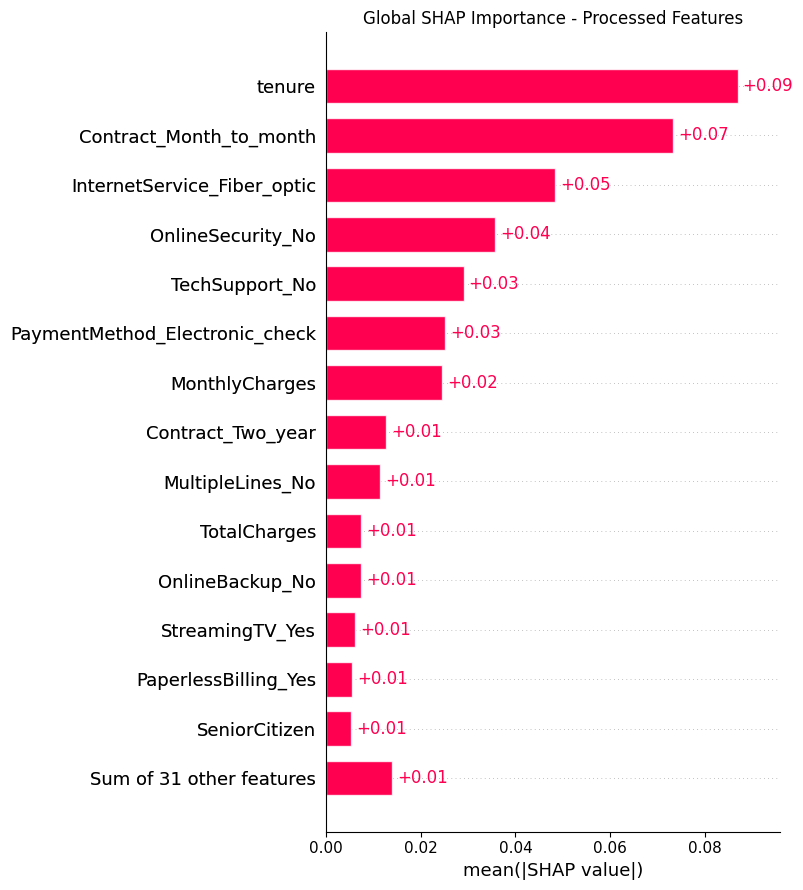

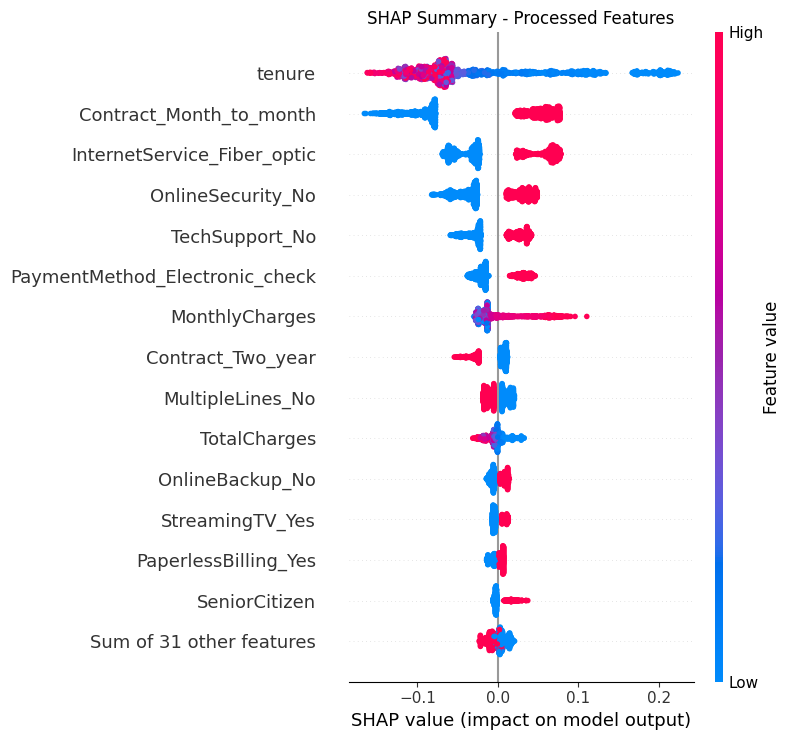

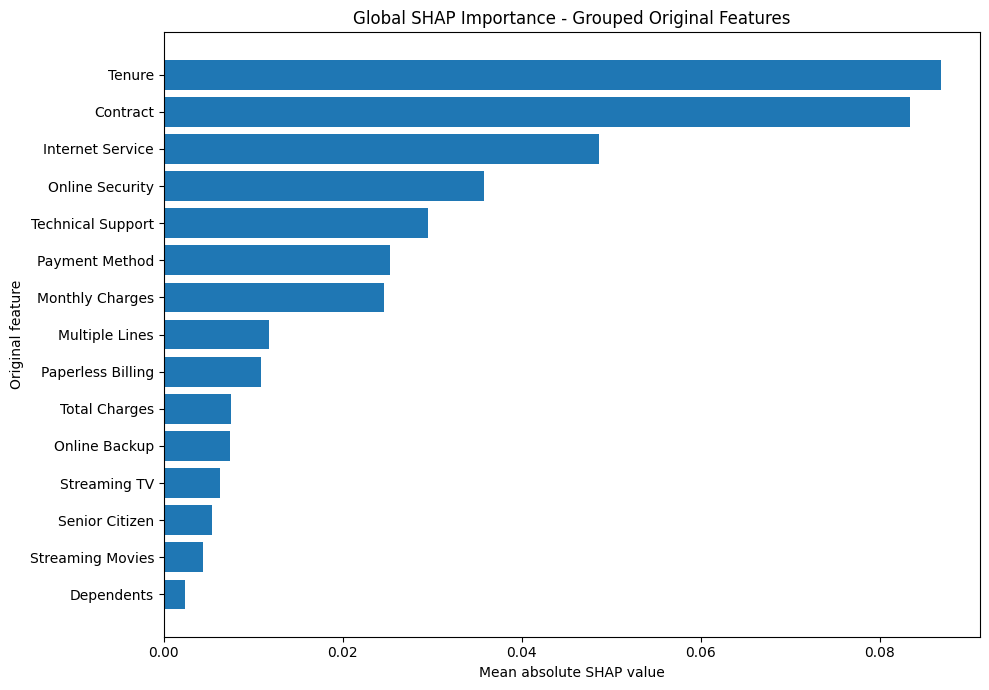


GLOBAL SHAP VISUALIZATIONS
Processed bar plot : /content/phase5_outputs/global_shap_bar_processed.png
Beeswarm plot      : /content/phase5_outputs/shap_beeswarm_processed.png
Grouped bar plot   : /content/phase5_outputs/global_shap_bar_grouped.png
Maximum features   : 15
SHAP output scale  : probability
Global SHAP visualizations were created successfully.


In [14]:
# ==========================================================
# Create Global SHAP Visualizations
# This step generates processed-feature and grouped-feature
# global importance plots and a SHAP beeswarm summary plot.
# ==========================================================

# Close any existing figures.
plt.close("all")

# Create the processed-feature SHAP bar plot.
shap.plots.bar(
    processed_explanation,
    max_display=15,
    show=False
)

plt.title(
    "Global SHAP Importance - Processed Features"
)

plt.tight_layout()

global_processed_plot_path = (
    PHASE5_DIR
    / "global_shap_bar_processed.png"
)

plt.savefig(
    global_processed_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

# Create the processed-feature SHAP beeswarm plot.
shap.plots.beeswarm(
    processed_explanation,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary - Processed Features"
)

plt.tight_layout()

beeswarm_plot_path = (
    PHASE5_DIR
    / "shap_beeswarm_processed.png"
)

plt.savefig(
    beeswarm_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

# Create a readable grouped original-feature bar plot.
top_grouped_features = (
    global_shap_importance_grouped
    .head(15)
    .sort_values(
        "MeanAbsoluteSHAP",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_grouped_features[
        "OriginalFeatureDisplayName"
    ],
    top_grouped_features[
        "MeanAbsoluteSHAP"
    ]
)

plt.xlabel(
    "Mean absolute SHAP value"
)

plt.ylabel(
    "Original feature"
)

plt.title(
    "Global SHAP Importance - Grouped Original Features"
)

plt.tight_layout()

global_grouped_plot_path = (
    PHASE5_DIR
    / "global_shap_bar_grouped.png"
)

plt.savefig(
    global_grouped_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

# Display the visualization summary.
print("\n" + "=" * 76)
print("GLOBAL SHAP VISUALIZATIONS")
print("=" * 76)
print("Processed bar plot :", global_processed_plot_path)
print("Beeswarm plot      :", beeswarm_plot_path)
print("Grouped bar plot   :", global_grouped_plot_path)
print("Maximum features   : 15")
print("SHAP output scale  :", SHAP_OUTPUT_SCALE)
print("=" * 76)
print("Global SHAP visualizations were created successfully.")

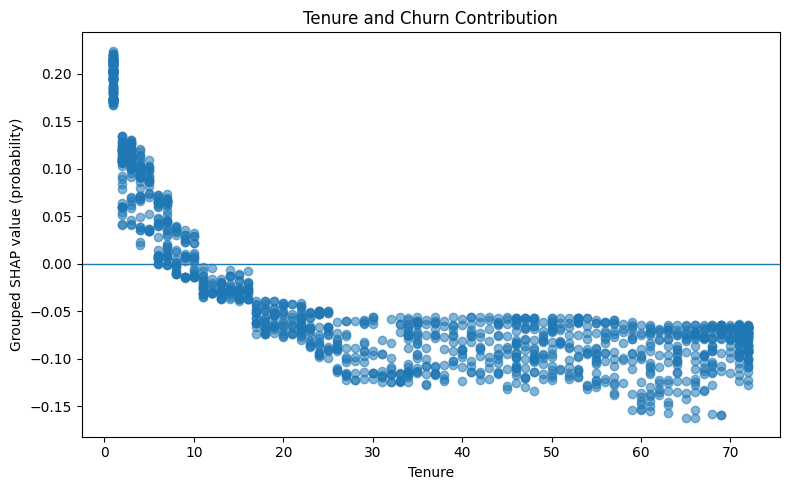

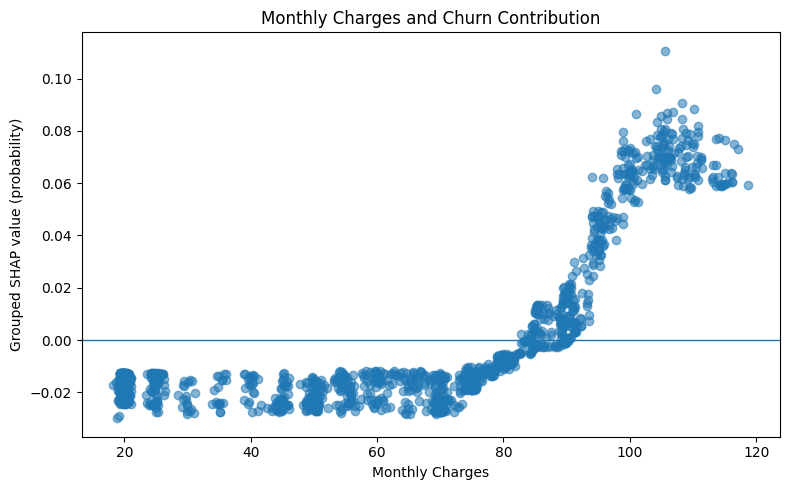


IMPORTANT FEATURE RELATIONSHIP PLOTS
Relationship features : ['tenure', 'MonthlyCharges']
Plots created         : 2
Saved plot            : /content/phase5_outputs/relationship_tenure.png
Saved plot            : /content/phase5_outputs/relationship_MonthlyCharges.png
Important feature relationships were examined successfully.


In [15]:
# ==========================================================
# Examine Important Numerical Feature Relationships
# This step creates a limited number of readable plots showing
# how original numerical values relate to SHAP contributions.
# ==========================================================

# Consider the three continuous original features.
continuous_relationship_candidates = [
    feature
    for feature in [
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
    if feature in GROUPED_FEATURE_ORDER
]

# Select the two most globally important continuous features.
relationship_features = (
    global_shap_importance_grouped[
        global_shap_importance_grouped[
            "OriginalFeatureName"
        ].isin(
            continuous_relationship_candidates
        )
    ]
    .sort_values(
        "MeanAbsoluteSHAP",
        ascending=False
    )[
        "OriginalFeatureName"
    ]
    .head(2)
    .tolist()
)

relationship_plot_files = []

# Create one relationship plot for each selected feature.
for feature in relationship_features:
    plt.figure(
        figsize=(8, 5)
    )

    plt.scatter(
        test_reference[
            feature
        ].astype(float),
        grouped_shap_values_df[
            feature
        ].astype(float),
        alpha=0.55
    )

    plt.axhline(
        0,
        linewidth=1
    )

    plt.xlabel(
        feature_display_names.get(
            feature,
            feature
        )
    )

    plt.ylabel(
        f"Grouped SHAP value ({SHAP_OUTPUT_SCALE})"
    )

    plt.title(
        f"{feature_display_names.get(feature, feature)} "
        "and Churn Contribution"
    )

    plt.tight_layout()

    relationship_filename = (
        f"relationship_{feature}.png"
    )

    relationship_path = (
        PHASE5_DIR
        / relationship_filename
    )

    plt.savefig(
        relationship_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    relationship_plot_files.append(
        relationship_filename
    )

# Display the summary.
print("\n" + "=" * 74)
print("IMPORTANT FEATURE RELATIONSHIP PLOTS")
print("=" * 74)
print("Relationship features :", relationship_features)
print("Plots created         :", len(relationship_plot_files))

for filename in relationship_plot_files:
    print("Saved plot            :", PHASE5_DIR / filename)

print("=" * 74)
print("Important feature relationships were examined successfully.")

In [16]:
# ==========================================================
# Select Representative Customers for Local Explanations
# This step selects high-risk, low-risk, correct, incorrect,
# and threshold-level customer examples.
# ==========================================================

representative_prediction_data = (
    test_predictions.copy()
)

# Select one customer according to specified conditions.
def select_representative_customer(
    example_label,
    condition,
    sort_column,
    ascending
):
    candidates = (
        representative_prediction_data.loc[
            condition
        ]
        .sort_values(
            sort_column,
            ascending=ascending
        )
    )

    if candidates.empty:
        return None

    selected_row = candidates.iloc[0]

    return {
        "ExampleType": example_label,
        "TestRowIndex": int(
            selected_row["TestRowIndex"]
        ),
        "customerID": str(
            selected_row["customerID"]
        ),
        "ActualChurn": int(
            selected_row["ActualChurn"]
        ),
        "PredictedChurn": int(
            selected_row["PredictedChurn"]
        ),
        "ChurnProbability": float(
            selected_row["ChurnProbability"]
        ),
        "DistanceFromSelectedThreshold": abs(
            float(
                selected_row[
                    "ChurnProbability"
                ]
            )
            - SELECTED_THRESHOLD
        )
    }

representative_rows = []

# Highest churn probability.
highest_probability_index = (
    representative_prediction_data[
        "ChurnProbability"
    ].idxmax()
)

highest_probability_example = (
    select_representative_customer(
        "Highest churn probability",
        representative_prediction_data.index
        == highest_probability_index,
        "ChurnProbability",
        False
    )
)

# Lowest churn probability.
lowest_probability_index = (
    representative_prediction_data[
        "ChurnProbability"
    ].idxmin()
)

lowest_probability_example = (
    select_representative_customer(
        "Lowest churn probability",
        representative_prediction_data.index
        == lowest_probability_index,
        "ChurnProbability",
        True
    )
)

# Correctly predicted churn.
true_positive_example = (
    select_representative_customer(
        "Correctly predicted churn",
        (
            representative_prediction_data[
                "ActualChurn"
            ] == 1
        )
        & (
            representative_prediction_data[
                "PredictedChurn"
            ] == 1
        ),
        "ChurnProbability",
        False
    )
)

# Correctly predicted non-churn.
true_negative_example = (
    select_representative_customer(
        "Correctly predicted non-churn",
        (
            representative_prediction_data[
                "ActualChurn"
            ] == 0
        )
        & (
            representative_prediction_data[
                "PredictedChurn"
            ] == 0
        ),
        "ChurnProbability",
        True
    )
)

# False-positive customer.
false_positive_example = (
    select_representative_customer(
        "False positive",
        (
            representative_prediction_data[
                "ActualChurn"
            ] == 0
        )
        & (
            representative_prediction_data[
                "PredictedChurn"
            ] == 1
        ),
        "ChurnProbability",
        False
    )
)

# False-negative customer.
false_negative_example = (
    select_representative_customer(
        "False negative",
        (
            representative_prediction_data[
                "ActualChurn"
            ] == 1
        )
        & (
            representative_prediction_data[
                "PredictedChurn"
            ] == 0
        ),
        "ChurnProbability",
        True
    )
)

# Add all available examples.
for example in [
    highest_probability_example,
    lowest_probability_example,
    true_positive_example,
    true_negative_example,
    false_positive_example,
    false_negative_example
]:
    if example is not None:
        representative_rows.append(example)

# Select the customer closest to the 0.27 threshold.
closest_threshold_index = (
    (
        representative_prediction_data[
            "ChurnProbability"
        ]
        - SELECTED_THRESHOLD
    )
    .abs()
    .idxmin()
)

closest_threshold_row = (
    representative_prediction_data.loc[
        closest_threshold_index
    ]
)

representative_rows.append({
    "ExampleType": "Closest to selected threshold",
    "TestRowIndex": int(
        closest_threshold_row[
            "TestRowIndex"
        ]
    ),
    "customerID": str(
        closest_threshold_row[
            "customerID"
        ]
    ),
    "ActualChurn": int(
        closest_threshold_row[
            "ActualChurn"
        ]
    ),
    "PredictedChurn": int(
        closest_threshold_row[
            "PredictedChurn"
        ]
    ),
    "ChurnProbability": float(
        closest_threshold_row[
            "ChurnProbability"
        ]
    ),
    "DistanceFromSelectedThreshold": abs(
        float(
            closest_threshold_row[
                "ChurnProbability"
            ]
        )
        - SELECTED_THRESHOLD
    )
})

representative_customer_examples = pd.DataFrame(
    representative_rows
)

# Save the selected examples.
representative_examples_path = (
    PHASE5_DIR
    / "representative_customer_examples.csv"
)

representative_customer_examples.to_csv(
    representative_examples_path,
    index=False
)

# Display the examples.
print("\n" + "=" * 80)
print("REPRESENTATIVE CUSTOMER EXAMPLES")
print("=" * 80)
print(
    "Selected prediction threshold :",
    SELECTED_THRESHOLD
)
print(
    "Examples selected             :",
    len(representative_customer_examples)
)
print(
    "Saved example file            :",
    representative_examples_path
)
print("=" * 80)

display(
    representative_customer_examples
)

print("Representative customer examples were selected successfully.")


REPRESENTATIVE CUSTOMER EXAMPLES
Selected prediction threshold : 0.27
Examples selected             : 7
Saved example file            : /content/phase5_outputs/representative_customer_examples.csv


,ExampleType,TestRowIndex,customerID,ActualChurn,PredictedChurn,ChurnProbability,DistanceFromSelectedThreshold
0,Highest churn probability,1149,5178-LMXOP,1,1,0.859534,0.589534
1,Lowest churn probability,246,0825-CPPQH,0,0,0.027568,0.242432
2,Correctly predicted churn,1149,5178-LMXOP,1,1,0.859534,0.589534
3,Correctly predicted non-churn,246,0825-CPPQH,0,0,0.027568,0.242432
4,False positive,211,5150-ITWWB,0,1,0.808563,0.538563
5,False negative,1201,3400-ESFUW,1,0,0.028512,0.241488
6,Closest to selected threshold,1402,1600-DILPE,0,1,0.270796,0.000796


Representative customer examples were selected successfully.


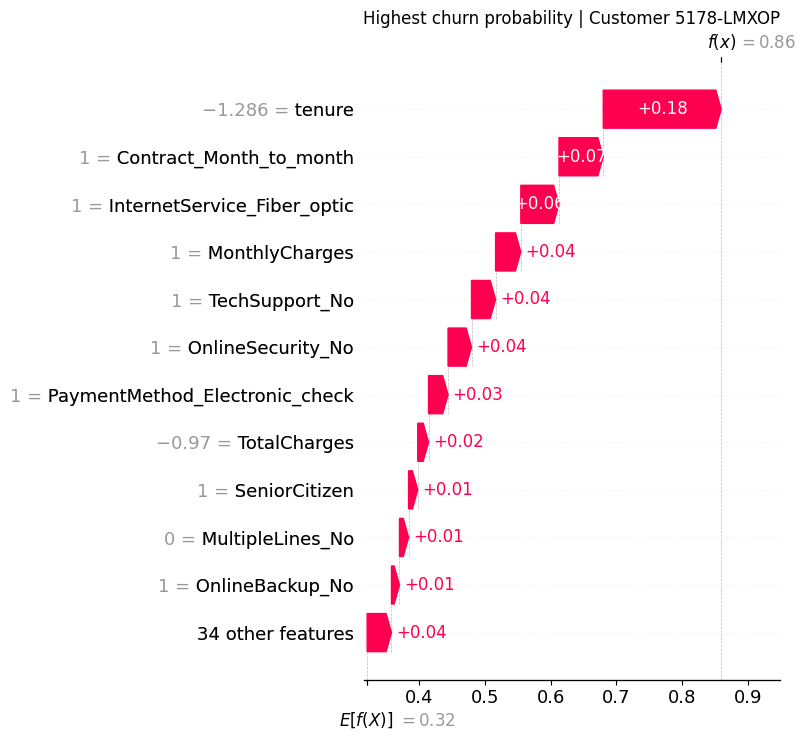

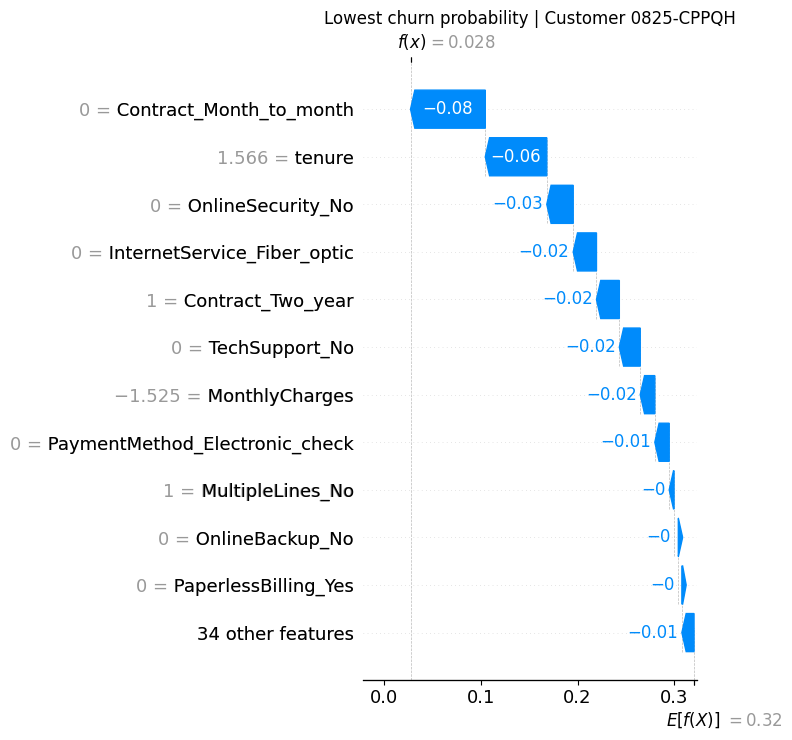

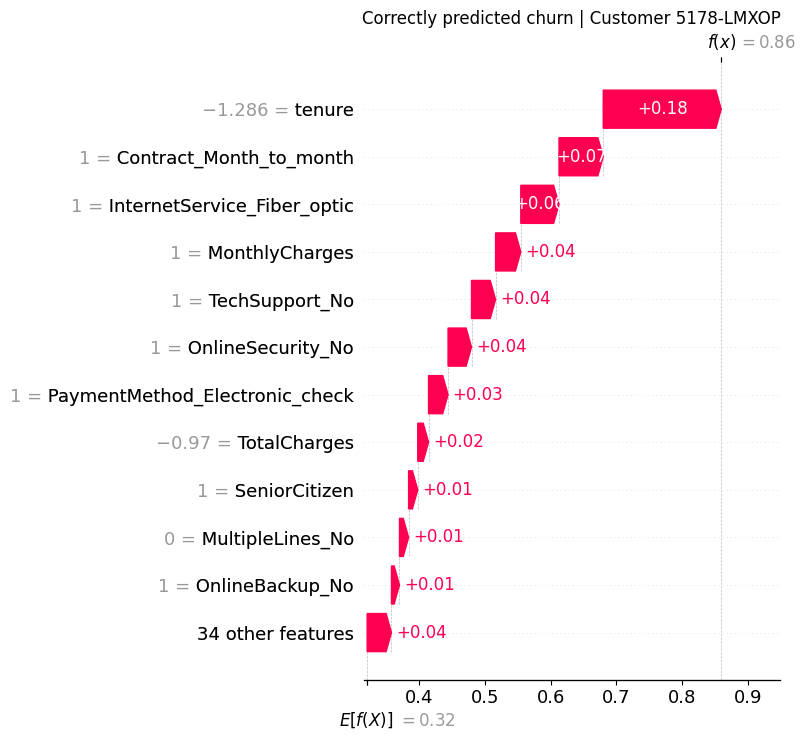

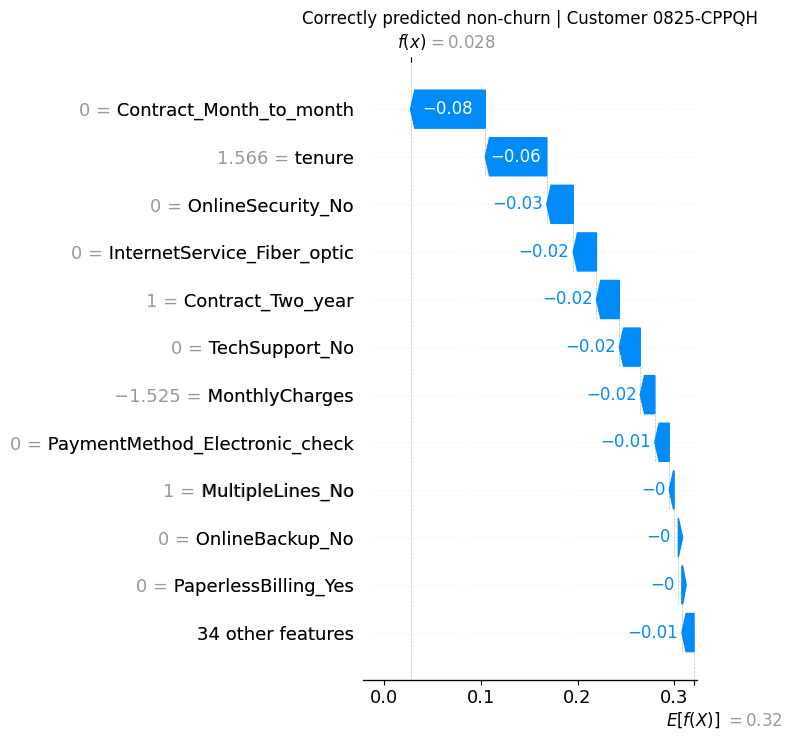

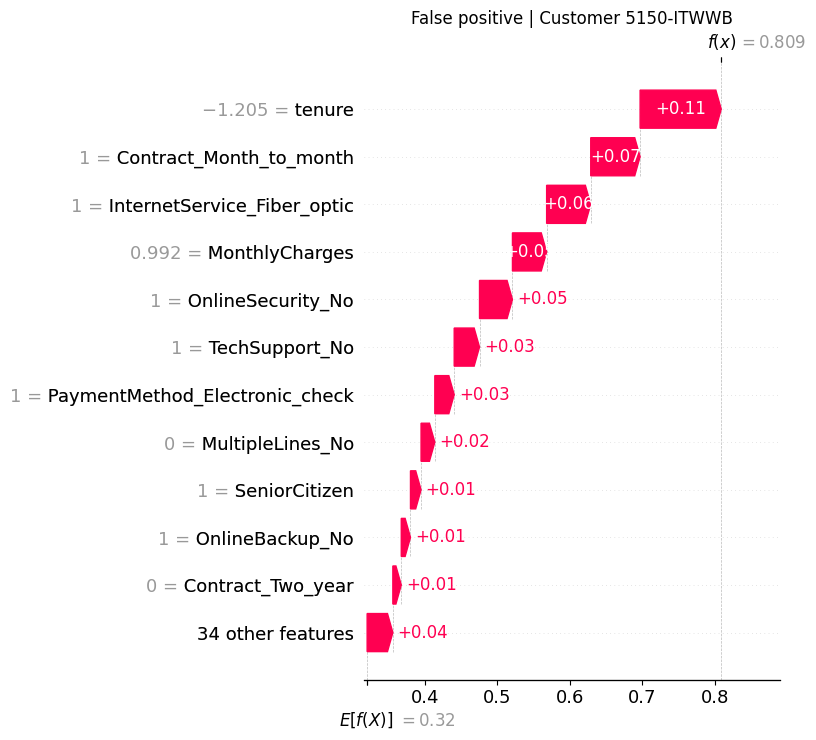

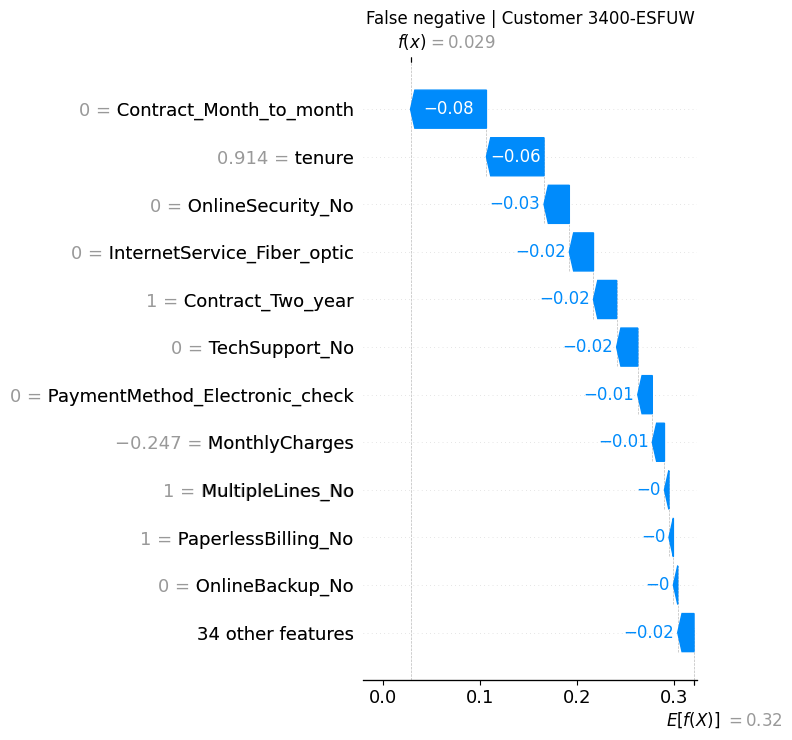

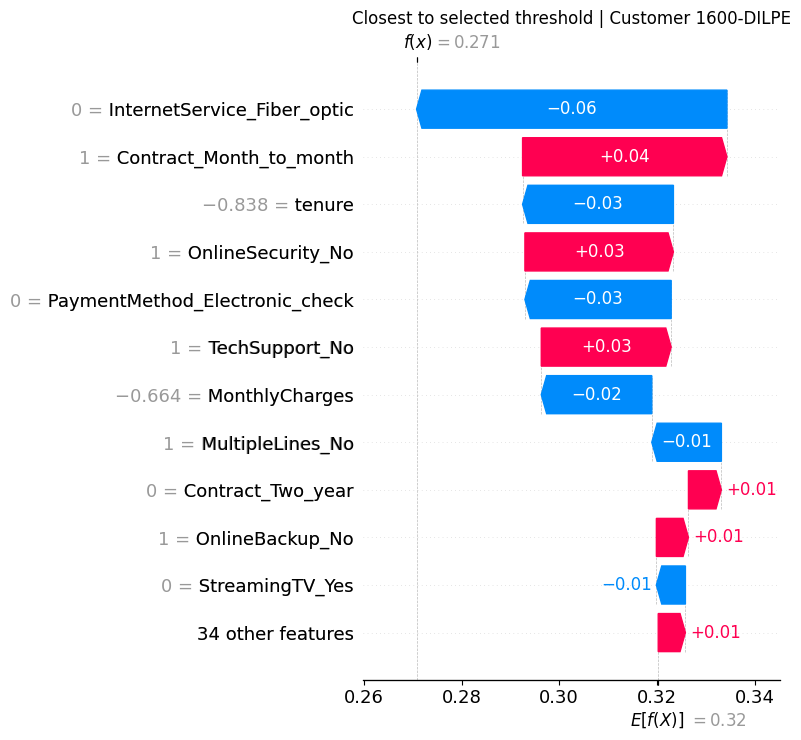


LOCAL CUSTOMER SHAP WATERFALL PLOTS
Representative examples : 7
Waterfall plots created  : 7
Maximum displayed factors: 12
Saved plot              : /content/phase5_outputs/waterfall_highest_churn_probability_5178-LMXOP.png
Saved plot              : /content/phase5_outputs/waterfall_lowest_churn_probability_0825-CPPQH.png
Saved plot              : /content/phase5_outputs/waterfall_correctly_predicted_churn_5178-LMXOP.png
Saved plot              : /content/phase5_outputs/waterfall_correctly_predicted_non_churn_0825-CPPQH.png
Saved plot              : /content/phase5_outputs/waterfall_false_positive_5150-ITWWB.png
Saved plot              : /content/phase5_outputs/waterfall_false_negative_3400-ESFUW.png
Saved plot              : /content/phase5_outputs/waterfall_closest_to_selected_threshold_1600-DILPE.png
Local SHAP waterfall explanations were created successfully.


In [17]:
# ==========================================================
# Generate Local SHAP Waterfall Plots
# This step creates individual explanations for the selected
# representative customer cases.
# ==========================================================

import re

waterfall_plot_files = []

# Create one waterfall plot for every representative example.
for _, example in representative_customer_examples.iterrows():
    test_row_index = int(
        example["TestRowIndex"]
    )

    safe_example_type = re.sub(
        r"[^A-Za-z0-9]+",
        "_",
        example["ExampleType"]
    ).strip("_").lower()

    safe_customer_id = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        str(example["customerID"])
    )

    waterfall_filename = (
        f"waterfall_{safe_example_type}_"
        f"{safe_customer_id}.png"
    )

    waterfall_path = (
        PHASE5_DIR
        / waterfall_filename
    )

    plt.close("all")

    shap.plots.waterfall(
        processed_explanation[
            test_row_index
        ],
        max_display=12,
        show=False
    )

    plt.title(
        f"{example['ExampleType']} | "
        f"Customer {example['customerID']}"
    )

    plt.tight_layout()

    plt.savefig(
        waterfall_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    waterfall_plot_files.append(
        waterfall_filename
    )

# Display the local explanation summary.
print("\n" + "=" * 80)
print("LOCAL CUSTOMER SHAP WATERFALL PLOTS")
print("=" * 80)
print(
    "Representative examples :",
    len(representative_customer_examples)
)
print(
    "Waterfall plots created  :",
    len(waterfall_plot_files)
)
print("Maximum displayed factors: 12")

for filename in waterfall_plot_files:
    print(
        "Saved plot              :",
        PHASE5_DIR / filename
    )

print("=" * 80)
print("Local SHAP waterfall explanations were created successfully.")

In [18]:
# ==========================================================
# Validate All Phase 5 Outputs and Save SHAP Metadata
# This step reloads key files, performs final consistency
# checks, and documents the complete SHAP configuration.
# ==========================================================

# Define the outputs that must exist.
required_phase5_outputs = [
    "shap_feature_mapping.csv",
    "shap_additivity_validation.csv",
    "global_shap_importance_processed.csv",
    "global_shap_importance_grouped.csv",
    "shap_values_processed_long.csv",
    "shap_values_grouped_long.csv",
    "shap_values_processed_wide.csv",
    "shap_values_grouped_wide.csv",
    "customer_shap_summary.csv",
    "customer_top_positive_factors.csv",
    "customer_top_negative_factors.csv",
    "customer_top_factors_combined.csv",
    "customer_prediction_explanations.csv",
    "representative_customer_examples.csv",
    "global_shap_bar_processed.png",
    "shap_beeswarm_processed.png",
    "global_shap_bar_grouped.png"
] + relationship_plot_files + waterfall_plot_files

# Reload important saved CSV files.
reloaded_processed_long = pd.read_csv(
    PHASE5_DIR
    / "shap_values_processed_long.csv"
)

reloaded_grouped_long = pd.read_csv(
    PHASE5_DIR
    / "shap_values_grouped_long.csv"
)

reloaded_customer_summary = pd.read_csv(
    PHASE5_DIR
    / "customer_shap_summary.csv"
)

# Create the final validation checks.
final_validation_checks = [
    (
        "Selected model loaded",
        type(selected_model).__name__
        == "GradientBoostingClassifier",
        type(selected_model).__name__
    ),
    (
        "Training data shape",
        X_train.shape
        == (
            expected_training_rows,
            expected_feature_count
        ),
        str(X_train.shape)
    ),
    (
        "Testing data shape",
        X_test.shape
        == (
            expected_testing_rows,
            expected_feature_count
        ),
        str(X_test.shape)
    ),
    (
        "Feature order matches saved model",
        X_test.columns.tolist()
        == model_feature_names,
        f"{len(model_feature_names)} features"
    ),
    (
        "Model probabilities match Phase 4",
        MAX_PROBABILITY_DIFFERENCE
        <= 1e-10,
        (
            "maximum difference="
            f"{MAX_PROBABILITY_DIFFERENCE:.3e}"
        )
    ),
    (
        "SHAP customer count",
        shap_values.shape[0]
        == len(X_test),
        str(shap_values.shape[0])
    ),
    (
        "SHAP feature count",
        shap_values.shape[1]
        == len(model_feature_names),
        str(shap_values.shape[1])
    ),
    (
        "SHAP values finite",
        np.isfinite(shap_values).all(),
        "No NaN or infinite values"
    ),
    (
        "Customer IDs aligned",
        test_reference[
            "customerID"
        ].astype(str).tolist()
        == test_predictions[
            "customerID"
        ].astype(str).tolist(),
        f"{len(test_reference)} IDs"
    ),
    (
        "Processed mapping complete",
        len(shap_feature_mapping)
        == len(model_feature_names),
        f"{len(shap_feature_mapping)} mappings"
    ),
    (
        "Grouped SHAP preserves contribution sum",
        GROUPING_MAX_DIFFERENCE
        <= 1e-10,
        (
            "maximum difference="
            f"{GROUPING_MAX_DIFFERENCE:.3e}"
        )
    ),
    (
        "SHAP additivity passed",
        MAX_ADDITIVITY_ERROR
        <= ADDITIVITY_TOLERANCE,
        (
            "maximum error="
            f"{MAX_ADDITIVITY_ERROR:.3e}"
        )
    ),
    (
        "Processed long file reloads",
        reloaded_processed_long.shape
        == (
            len(X_test)
            * len(model_feature_names),
            len(processed_shap_long.columns)
        ),
        str(reloaded_processed_long.shape)
    ),
    (
        "Grouped long file reloads",
        reloaded_grouped_long.shape
        == (
            len(X_test)
            * len(GROUPED_FEATURE_ORDER),
            len(grouped_shap_long.columns)
        ),
        str(reloaded_grouped_long.shape)
    ),
    (
        "Customer summary reloads",
        len(reloaded_customer_summary)
        == len(X_test),
        str(reloaded_customer_summary.shape)
    ),
    (
        "All required output files exist",
        all(
            (
                PHASE5_DIR
                / filename
            ).exists()
            for filename
            in required_phase5_outputs
        ),
        (
            f"{sum((PHASE5_DIR / filename).exists() for filename in required_phase5_outputs)}"
            f"/{len(required_phase5_outputs)} files"
        )
    )
]

# Convert checks into a readable validation table.
phase5_validation_summary = pd.DataFrame([
    {
        "Check": check_name,
        "Status": (
            "PASS"
            if passed
            else "FAIL"
        ),
        "Details": details
    }
    for check_name, passed, details
    in final_validation_checks
])

validation_summary_path = (
    PHASE5_DIR
    / "phase5_validation_summary.csv"
)

phase5_validation_summary.to_csv(
    validation_summary_path,
    index=False
)

# Stop if any final validation failed.
failed_validations = (
    phase5_validation_summary[
        phase5_validation_summary[
            "Status"
        ] == "FAIL"
    ]
)

if not failed_validations.empty:
    raise AssertionError(
        "One or more Phase 5 validation checks failed:\n"
        + failed_validations.to_string(index=False)
    )

# Create complete SHAP metadata.
shap_metadata = {
    "phase": (
        "Phase 5 - Explainable Artificial "
        "Intelligence with SHAP"
    ),
    "thesis_title": model_metadata.get(
        "thesis_title"
    ),
    "selected_model_name": model_metadata.get(
        "selected_model_name"
    ),
    "model_class": type(selected_model).__name__,
    "positive_class": POSITIVE_CLASS,
    "positive_class_description": (
        "Customer churn"
    ),
    "prediction_threshold": SELECTED_THRESHOLD,
    "shap_version": shap.__version__,
    "explainer_type": EXPLAINER_TYPE,
    "shap_output_scale": SHAP_OUTPUT_SCALE,
    "probability_scale_attempted": True,
    "fallback_reason": SHAP_FALLBACK_REASON,
    "background_sample_size": (
        BACKGROUND_SAMPLE_SIZE
    ),
    "training_records": len(X_train),
    "testing_records": len(X_test),
    "processed_feature_count": (
        len(model_feature_names)
    ),
    "grouped_original_feature_count": (
        len(GROUPED_FEATURE_ORDER)
    ),
    "grouping_method": (
        "SHAP contributions of processed columns "
        "belonging to the same original feature "
        "were summed for each customer."
    ),
    "top_factors_per_direction": (
        TOP_FACTORS_PER_DIRECTION
    ),
    "neutral_tolerance": NEUTRAL_TOLERANCE,
    "additivity_tolerance": (
        ADDITIVITY_TOLERANCE
    ),
    "maximum_additivity_error": (
        MAX_ADDITIVITY_ERROR
    ),
    "mean_additivity_error": (
        MEAN_ADDITIVITY_ERROR
    ),
    "maximum_probability_reproduction_difference": (
        MAX_PROBABILITY_DIFFERENCE
    ),
    "maximum_grouping_difference": (
        GROUPING_MAX_DIFFERENCE
    ),
    "random_state": RANDOM_STATE,
    "data_scope": (
        "Independent Phase 4 test dataset"
    ),
    "explanation_target": (
        "Positive class Churn = 1"
    ),
    "output_files": sorted(
        [
            path.name
            for path in PHASE5_DIR.iterdir()
            if path.is_file()
        ]
        + ["shap_metadata.json"]
    )
}

shap_metadata_path = (
    PHASE5_DIR
    / "shap_metadata.json"
)

with open(
    shap_metadata_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        shap_metadata,
        file,
        indent=2
    )

# Display the validation results.
print("\n" + "=" * 82)
print("FINAL PHASE 5 VALIDATION")
print("=" * 82)

display(
    phase5_validation_summary
)

print("Validation summary file :", validation_summary_path)
print("SHAP metadata file      :", shap_metadata_path)
print("Validation failures     :", len(failed_validations))
print("=" * 82)
print("All Phase 5 validation checks passed successfully.")


FINAL PHASE 5 VALIDATION


,Check,Status,Details
0,Selected model loaded,PASS,GradientBoostingClassifier
1,Training data shape,PASS,"(5625, 45)"
2,Testing data shape,PASS,"(1407, 45)"
3,Feature order matches saved model,PASS,45 features
4,Model probabilities match Phase 4,PASS,maximum difference=9.714e-17
5,SHAP customer count,PASS,1407
6,SHAP feature count,PASS,45
7,SHAP values finite,PASS,No NaN or infinite values
8,Customer IDs aligned,PASS,1407 IDs
9,Processed mapping complete,PASS,45 mappings


Validation summary file : /content/phase5_outputs/phase5_validation_summary.csv
SHAP metadata file      : /content/phase5_outputs/shap_metadata.json
Validation failures     : 0
All Phase 5 validation checks passed successfully.


In [19]:
# ==========================================================
# Create the Final Phase 5 SHAP Output ZIP
# This final step compresses all SHAP files, validates the ZIP,
# displays the final summary, and starts the ZIP download.
# ==========================================================

from google.colab import files

PHASE5_ZIP_PATH = Path(
    "/content/Phase_5_SHAP_Outputs.zip"
)

# Remove an older ZIP if this cell is run again.
if PHASE5_ZIP_PATH.exists():
    PHASE5_ZIP_PATH.unlink()

# Add every Phase 5 output file to the ZIP archive.
with zipfile.ZipFile(
    PHASE5_ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:
    for output_path in sorted(
        PHASE5_DIR.iterdir()
    ):
        if output_path.is_file():
            zip_file.write(
                output_path,
                arcname=output_path.name
            )

# Validate the ZIP archive.
with zipfile.ZipFile(
    PHASE5_ZIP_PATH,
    "r"
) as zip_file:
    zipped_filenames = zip_file.namelist()
    damaged_file = zip_file.testzip()

if damaged_file is not None:
    raise RuntimeError(
        f"The ZIP contains a damaged file: {damaged_file}"
    )

expected_zip_file_count = len([
    path
    for path in PHASE5_DIR.iterdir()
    if path.is_file()
])

if (
    len(zipped_filenames)
    != expected_zip_file_count
):
    raise AssertionError(
        "The number of files in the ZIP is incorrect."
    )

# Calculate ZIP size.
phase5_zip_size_mb = (
    PHASE5_ZIP_PATH.stat().st_size
    / (1024 ** 2)
)

# Display the final global importance results.
print("\n" + "=" * 86)
print("TOP 10 GROUPED ORIGINAL FEATURES")
print("=" * 86)

display(
    global_shap_importance_grouped[
        [
            "GlobalImportanceRank",
            "OriginalFeatureDisplayName",
            "MeanAbsoluteSHAP",
            "MeanSHAP"
        ]
    ].head(10)
)

# Display the final Phase 5 summary.
print("\n" + "=" * 86)
print("PHASE 5 — FINAL SHAP ANALYSIS SUMMARY")
print("=" * 86)
print(
    "Selected model                 :",
    type(selected_model).__name__
)
print(
    "Positive class                 :",
    "Churn = 1"
)
print(
    "Prediction threshold           :",
    SELECTED_THRESHOLD
)
print(
    "SHAP explainer                 :",
    EXPLAINER_TYPE
)
print(
    "SHAP output scale              :",
    SHAP_OUTPUT_SCALE
)
print(
    "Customers explained            :",
    shap_values.shape[0]
)
print(
    "Processed features explained   :",
    shap_values.shape[1]
)
print(
    "Grouped original features      :",
    len(GROUPED_FEATURE_ORDER)
)
print(
    "Processed long-format rows     :",
    len(processed_shap_long)
)
print(
    "Grouped long-format rows       :",
    len(grouped_shap_long)
)
print(
    "Maximum additivity error       :",
    f"{MAX_ADDITIVITY_ERROR:.12e}"
)
print(
    "Maximum grouping difference    :",
    f"{GROUPING_MAX_DIFFERENCE:.12e}"
)
print(
    "Probability reproduction error :",
    f"{MAX_PROBABILITY_DIFFERENCE:.12e}"
)
print(
    "Final validation failures      :",
    len(failed_validations)
)
print(
    "Files in final ZIP             :",
    len(zipped_filenames)
)
print(
    "Final ZIP size                 :",
    f"{phase5_zip_size_mb:.2f} MB"
)
print(
    "Final ZIP path                 :",
    PHASE5_ZIP_PATH
)
print("=" * 86)
print("Phase 5 SHAP analysis completed successfully.")
print("The final Phase 5 ZIP archive is ready for download.")

# Start downloading the completed ZIP archive.
files.download(
    str(PHASE5_ZIP_PATH)
)


TOP 10 GROUPED ORIGINAL FEATURES


,GlobalImportanceRank,OriginalFeatureDisplayName,MeanAbsoluteSHAP,MeanSHAP
0,1,Tenure,0.086874,-0.024689
1,2,Contract,0.083423,-0.013719
2,3,Internet Service,0.048631,0.001456
3,4,Online Security,0.035766,-0.004926
4,5,Technical Support,0.029579,-0.001422
5,6,Payment Method,0.025229,-0.004297
6,7,Monthly Charges,0.024565,0.000905
7,8,Multiple Lines,0.011716,0.000711
8,9,Paperless Billing,0.010842,-0.000831
9,10,Total Charges,0.007523,-0.002292



PHASE 5 — FINAL SHAP ANALYSIS SUMMARY
Selected model                 : GradientBoostingClassifier
Positive class                 : Churn = 1
Prediction threshold           : 0.27
SHAP explainer                 : TreeExplainer with interventional background
SHAP output scale              : probability
Customers explained            : 1407
Processed features explained   : 45
Grouped original features      : 19
Processed long-format rows     : 63315
Grouped long-format rows       : 26733
Maximum additivity error       : 3.381192770213e-09
Maximum grouping difference    : 2.220446049250e-16
Probability reproduction error : 9.714451465470e-17
Final validation failures      : 0
Files in final ZIP             : 28
Final ZIP size                 : 5.18 MB
Final ZIP path                 : /content/Phase_5_SHAP_Outputs.zip
Phase 5 SHAP analysis completed successfully.
The final Phase 5 ZIP archive is ready for download.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>